# New Dataset Preparation - Expanded

### Packages

In [1]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error, r2_score

# imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
# import functions_enc as f
import function_depot as fd

# Data Processing

### DF5 Upload

GROUP STATISTICS 
Group                     Total Spectra   Unique SMILES  
LTQ-Orbitrap-negative     121             23             
LTQ-Orbitrap-positive     615             70             
LTQ-negative              13              10             
LTQ-positive              12              2              
Other-negative            12              8              
Other-positive            79              25             
Q-Orbitrap-negative       1400            252            
Q-Orbitrap-positive       2065            378            
Q-TOF-negative            235             56             
Q-TOF-positive            1098            221            
QQQ-negative              162             34             
QQQ-positive              286             85             

Total across all groups: 6098            678      

The code that produced this

Print group statistics for unique SMILES and spectra counts
print("=== GROUP STATISTICS ===")
print(f"{'Group':<25} {'Total Spectra':<15} {'Unique SMILES':<15}")
print("-" * 55)

for group in sorted(df5['Group'].unique()):
    group_data = df5[df5['Group'] == group]
    total_spectra = len(group_data)
    unique_smiles = group_data['SMILES_spectra'].nunique()
    
    print(f"{group:<25} {total_spectra:<15} {unique_smiles:<15}")

print(f"\nTotal across all groups: {len(df5):<15} {df5['SMILES_spectra'].nunique():<15}")

Groups included: ['Q-Orbitrap-positive' 'Q-TOF-positive' 'LTQ-Orbitrap-positive']
Unique SMILES: 485

In [2]:
# We are working with the June 25 dataset, with the Morgan Fingerprints and cannonical SMILES included
df5 = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/MIT_LL_data5.csv")
# print(df5.shape)
# df5.head()

# First order of business is to standardize our SMILES column. We want to use canonical smiles rather than SMILES_spectra but 
# we will keep the column name SMILES_spectra for consistency with previous code
df5 = df5.drop('SMILES_spectra', axis=1) # Drop
df5 = df5.rename(columns={'canonical_smiles': 'SMILES_spectra'}) # Rename
cols = df5.columns.tolist()
cols.remove('SMILES_spectra') 
df5 = df5[['SMILES_spectra'] + cols] # Move to front

# Next we want to standardize the Ionization column
# print(df5["Ionization_Mode"].unique()) # Check unique values
df5["Ionization_Mode"] = df5["Ionization_Mode"].replace("'Positive'", "'positive'") # Fix capitaliztion
df5 = df5[df5["Ionization_Mode"] != "'N/A'"] # Remove N/A 
# print(df5["Ionization_Mode"].unique()) # Check unique values

# Remove single quotes from all columns
df5 = df5.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)

# Select specific groups for subset
selected_groups = ['Q-Orbitrap-positive', 'Q-TOF-positive', 'LTQ-Orbitrap-positive']

# Create subset with only selected groups
df5_subset = df5[df5['Group'].isin(selected_groups)]

print(df5_subset.shape)
df5_subset.head()

(3778, 18)


,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group,fp,filtered_fp
0,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.177223 65.0386:5.629055 68.0495:0.45...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,90 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.125979 65.0386:2.113734 68.0495:0.68...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,75 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.115017 65.0386:0.970445 68.0495:1.03...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,60 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,51.0229:0.102992 56.0495:0.143820 65.0386:0.67...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,45 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.482623 65.0385:0.377829 68.0495:2.59...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,30 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


### Dataframe Creation - Added to MIT_LL_data directory

In [3]:
# DF5 SUBSET DATAFRAME
# df5_subset.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_subset.parquet', index=False)


# # # Save the dataframes to data folder as parquet files
# # df5_spectra.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.parquet', index=False)
# df5_chemnet.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet', index=False)
# # df5_morganfp.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.parquet', index=False)


In [4]:
# SPECTRA DATAFRAME
# Create dataframe with spectra using spectrum_string_to_dataframe
df5_spectra = fd.spectrum_string_to_dataframe(df5_subset, spectrum_col='Spectrum', smiles_col='SMILES_spectra')

# Add Group and Response columns by mapping directly from df5_subset
# Create dictionaries for faster lookup
smiles_to_group = df5_subset.set_index('SMILES_spectra')['Group'].to_dict()
smiles_to_response = df5_subset.set_index('SMILES_spectra')['Response'].to_dict()

# Map the values directly
df5_spectra['Group'] = df5_spectra['SMILES_spectra'].map(smiles_to_group)
df5_spectra['Response'] = df5_spectra['SMILES_spectra'].map(smiles_to_response)

# Remove columns with m/z values greater than 900
columns_to_keep = []
for col in df5_spectra.columns:
    # Keep non-numeric columns (SMILES_spectra, Group, Response)
    if col in ['SMILES_spectra', 'Group', 'Response', 'index_id']:
        columns_to_keep.append(col)
    else:
        try:
            # Check if column name can be converted to float and is <= 900
            mz_value = float(col)
            if mz_value <= 900:
                columns_to_keep.append(col)
        except (ValueError, TypeError):
            # Keep columns that can't be converted to float (non-m/z columns)
            columns_to_keep.append(col)

# Filter the dataframe to only keep desired columns
df5_spectra = df5_spectra[columns_to_keep]

print("=== SPECTRA DATAFRAME (FILTERED) ===")
print(f"Shape: {df5_spectra.shape}")
print(f"Unique SMILES: {df5_spectra['SMILES_spectra'].nunique()}")
print(f"Columns: {list(df5_spectra.columns[:3])} ... {list(df5_spectra.columns[-3:])}")  # Show first and last few columns

# Optional: Print how many m/z columns were removed
original_cols = len([col for col in df5_spectra.columns if col not in ['SMILES_spectra', 'Group', 'Response']])
removed_cols = len([col for col in df5_spectra.columns if col not in ['SMILES_spectra', 'Group', 'Response']]) 
print(f"Kept m/z columns <= 900. Remaining spectral features: {len(columns_to_keep) - 3}")
df5_spectra.head()

=== SPECTRA DATAFRAME (FILTERED) ===
Shape: (3778, 64106)
Unique SMILES: 485
Columns: ['SMILES_spectra', 29.0112, 30.032] ... ['index_id', 'Group', 'Response']
Kept m/z columns <= 900. Remaining spectral features: 64103


,SMILES_spectra,29.0112,30.032,30.0323,31.01686,31.54035,38.5076,39.0214,39.0215,39.02194,...,883.572754,884.950439,886.320984,889.633972,893.959961,895.855774,898.654114,index_id,Group,Response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Q-Orbitrap-positive,273.642508
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Q-Orbitrap-positive,273.642508
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,Q-Orbitrap-positive,273.642508
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,Q-Orbitrap-positive,273.642508
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,Q-Orbitrap-positive,273.642508


In [5]:
# # CHEMNET EMBEDDINGS
# # Create ChemNet embeddings dataframe using get_chemnet_emb_from_smiles
# unique_smiles = df5_subset['SMILES_spectra'].unique().tolist()
# print(f"Getting ChemNet embeddings for {len(unique_smiles)} unique SMILES...")

# # Get embeddings dictionary
# embeddings_dict = fd.get_chemnet_emb_from_smiles(unique_smiles)

# # Convert to dataframe format
# embeddings_data = []
# for smiles, embedding in embeddings_dict.items():
#     if embedding != 'unknown':  # Skip unknown embeddings
#         row = {'SMILES_spectra': smiles}
#         # Add each embedding dimension as a separate column
#         for i, emb_val in enumerate(embedding):
#             row[f'Embedding Float {i}'] = emb_val
#         embeddings_data.append(row)

# df5_chemnet = pd.DataFrame(embeddings_data)

# print("\n=== EMBEDDINGS DATAFRAME ===")
# print(f"Shape: {df5_chemnet.shape}")
# print(f"Unique SMILES: {df5_chemnet['SMILES_spectra'].nunique()}")
# print(f"Embedding dimensions: {df5_chemnet.shape[1] - 1}")  # -1 for SMILES column
# df5_chemnet.head()

In [6]:
# # MORGAN FINGERPRINTS
# # Create dataframe with just SMILES and Morgan fingerprints using expand_fingerprints_to_matrix
# df5_morganfp= fd.expand_fingerprints_to_matrix(df5_subset, smiles_col='SMILES_spectra', fp_col='fp')

# print("\n=== FINGERPRINTS DATAFRAME ===")
# print(f"Shape: {df5_morganfp.shape}")
# print(f"Unique SMILES: {df5_morganfp['SMILES_spectra'].nunique()}")
# df5_morganfp.head()

In [7]:
# # Save the datafames to data folder
# df5_spectra = df5_spectra.to_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.csv', index=False)
# df5_chemnet = df5_chemnet.to_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.csv', index=False)
# df5_morganfp = df5_morganfp.to_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.csv', index=False)

# # Load dataframes into notebook - Beware, these can take a while to load
# df5_spectra = pd.read_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.csv')
# df5_chemnet = pd.read_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.csv')
# df5_morganfp = pd.read_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.csv')


# Binning

In [8]:
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_1_thresh0_1_df_spectra.pkl')
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_1_thresh100_df_spectra.pkl')
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_05_thresh0_1_df_spectra.pkl')
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_05_thresh100_df_spectra.pkl')
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin500_thresh50_df_spectra.pkl')
# df.head()

In [9]:
# Define your parameters
bin_sizes = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
thresholds = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
save_directory = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

# Create all datasets
# all_datasets = fd.binning_loop(df5_spectra, df5_subset, bin_sizes, thresholds, save_directory, indx_id_indx=-3, startindx=1, stopindx=-3)

In [10]:
# DF5 SUBSET DATAFRAME
# df5_subset.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_subset.parquet', index=False)


# # # Save the dataframes to data folder as parquet files
# df5_spectra.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.parquet', index=False)
# df5_chemnet.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet', index=False)
# df5_morganfp.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.parquet', index=False)


# Spectra RF and Heatmap

Processing single dataset: bin0_1_thresh0_1_df_spectra
Loaded dataset shape: (3778, 11618)
Columns: ['SMILES_spectra', 0.05, 0.15000000000000002, 0.25, 0.35, 0.44999999999999996, 0.5499999999999999, 0.6499999999999999, 0.7499999999999999, 0.8499999999999999, 0.9499999999999998, 1.0499999999999998, 1.15, 1.25, 1.35, 1.4500000000000002, 1.5500000000000003, 1.6500000000000004, 1.7500000000000004, 1.8500000000000005, 1.9500000000000006, 2.0500000000000007, 2.150000000000001, 2.250000000000001, 2.350000000000001, 2.450000000000001, 2.550000000000001, 2.6500000000000012, 2.7500000000000013, 2.8500000000000014, 2.9500000000000015, 3.0500000000000016, 3.1500000000000017, 3.2500000000000018, 3.350000000000002, 3.450000000000002, 3.550000000000002, 3.650000000000002, 3.750000000000002, 3.8500000000000023, 3.9500000000000024, 4.0500000000000025, 4.150000000000002, 4.250000000000002, 4.350000000000001, 4.450000000000001, 4.550000000000001, 4.65, 4.75, 4.85, 4.949999999999999, 5.049999999999999, 5.

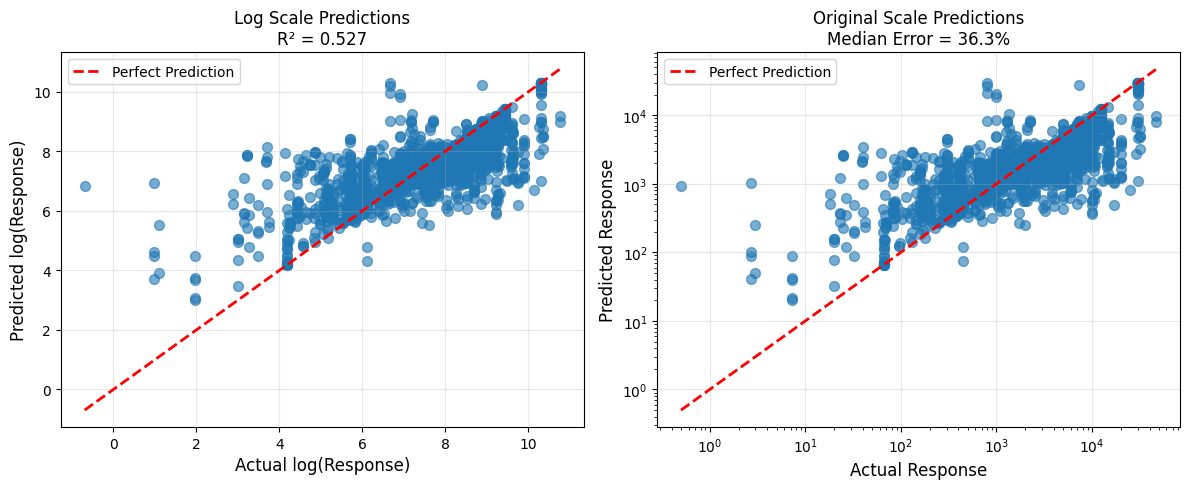

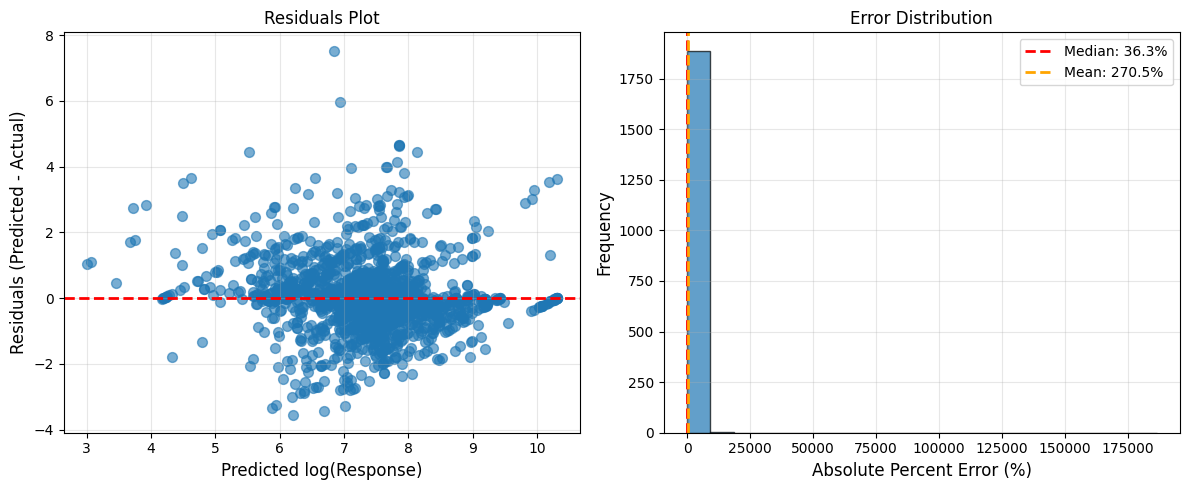


Analysis complete for bin0_1_thresh0_1_df_spectra


In [11]:
# Load and analyze a single dataset
dataset_name = "bin0_1_thresh0_1_df_spectra"  # Change this to your desired dataset
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

print(f"Processing single dataset: {dataset_name}")

try:
    # Load the single dataset
    file_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
    df = pd.read_pickle(file_path)
    
    print(f"Loaded dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    # Prepare features and target
    feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
    X = df[feature_cols]
    y = df['log_response']
    
    print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}...")  # Show first 5 feature columns
    
    # Remove rows with NaN values
    valid_mask = ~(X.isna().any(axis=1) | y.isna())
    X_clean = X[valid_mask]
    y_clean = y[valid_mask]
    
    print(f"Clean data shape: X={X_clean.shape}, y={y_clean.shape}")
    
    if len(X_clean) < 10:
        print(f"Error: Only {len(X_clean)} valid samples - need at least 10")
    else:
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.5, random_state=42
        )
        
        print(f"Train/Test split: {X_train.shape[0]} / {X_test.shape[0]} samples")
        
        # Train Random Forest
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
        rf.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Print results
        print(f"\n=== RESULTS FOR {dataset_name} ===")
        print(f"Train R²: {train_r2:.4f}")
        print(f"Test R²: {test_r2:.4f}")
        print(f"Train Median % Error: {train_median_percent_error:.1f}%")
        print(f"Test Median % Error: {test_median_percent_error:.1f}%")
        print(f"Train Mean % Error: {train_mean_percent_error:.1f}%")
        print(f"Test Mean % Error: {test_mean_percent_error:.1f}%")
        print(f"Number of samples: {len(X_clean)}")
        print(f"Number of features: {len(feature_cols)}")
        
        # Store in single result dictionary
        single_result = {
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols),
            'Individual_Errors': individual_errors
        }
        # === ACCURACY ILLUSTRATION PLOTS ===
        
        # 1. Predicted vs Actual scatter plot (log scale)
        plt.figure(figsize=(12, 5))
        
        # Left subplot: Log-transformed values
        plt.subplot(1, 2, 1)
        plt.scatter(y_test, y_test_pred, alpha=0.6, s=50)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
        plt.xlabel('Actual log(Response)', fontsize=12)
        plt.ylabel('Predicted log(Response)', fontsize=12)
        plt.title(f'Log Scale Predictions\nR² = {test_r2:.3f}', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Right subplot: Original scale (undoing log transform)
        plt.subplot(1, 2, 2)
        plt.scatter(y_test_true_response, y_test_pred_response, alpha=0.6, s=50)
        plt.plot([y_test_true_response.min(), y_test_true_response.max()], 
                 [y_test_true_response.min(), y_test_true_response.max()], 'r--', lw=2, label='Perfect Prediction')
        plt.xlabel('Actual Response', fontsize=12)
        plt.ylabel('Predicted Response', fontsize=12)
        plt.title(f'Original Scale Predictions\nMedian Error = {test_median_percent_error:.1f}%', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xscale('log')
        plt.yscale('log')
        
        plt.tight_layout()
        plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/RF_Accuracy_{dataset_name}.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # 2. Residuals and error distribution plot
        plt.figure(figsize=(12, 5))
        
        # Left subplot: Residuals plot
        plt.subplot(1, 2, 1)
        residuals = y_test_pred - y_test
        plt.scatter(y_test_pred, residuals, alpha=0.6, s=50)
        plt.axhline(y=0, color='r', linestyle='--', lw=2)
        plt.xlabel('Predicted log(Response)', fontsize=12)
        plt.ylabel('Residuals (Predicted - Actual)', fontsize=12)
        plt.title('Residuals Plot', fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # Right subplot: Error distribution histogram
        plt.subplot(1, 2, 2)
        plt.hist(individual_errors, bins=20, alpha=0.7, edgecolor='black')
        plt.axvline(test_median_percent_error, color='red', linestyle='--', linewidth=2, 
                   label=f'Median: {test_median_percent_error:.1f}%')
        plt.axvline(test_mean_percent_error, color='orange', linestyle='--', linewidth=2, 
                   label=f'Mean: {test_mean_percent_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Error Distribution', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/RF_ErrorAnalysis_{dataset_name}.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"\nAnalysis complete for {dataset_name}")
        
except Exception as e:
    print(f"Error processing {dataset_name}: {str(e)}")
    import traceback
    traceback.print_exc()

Processing dataset with different training set sizes: bin0_1_thresh0_1_df_spectra


Loaded dataset shape: (3778, 11618)
Clean data shape: X=(3778, 11616), y=(3778,)

--- Training with 80% / 20% split ---
Train/Test split: 3022 / 756 samples
Train R²: 0.9422, Test R²: 0.6352
Train Median Error: 12.4%, Test Median Error: 29.4%
Train Mean Error: 26.0%, Test Mean Error: 144.9%

--- Training with 60% / 40% split ---
Train/Test split: 2266 / 1512 samples
Train R²: 0.9423, Test R²: 0.5424
Train Median Error: 13.7%, Test Median Error: 34.9%
Train Mean Error: 26.1%, Test Mean Error: 293.2%

--- Training with 40% / 60% split ---
Train/Test split: 1511 / 2267 samples
Train R²: 0.9352, Test R²: 0.4708
Train Median Error: 15.5%, Test Median Error: 39.5%
Train Mean Error: 29.0%, Test Mean Error: 259.1%

--- Training with 20% / 80% split ---
Train/Test split: 755 / 3023 samples
Train R²: 0.9083, Test R²: 0.3924
Train Median Error: 21.1%, Test Median Error: 51.0%
Train Mean Error: 39.2%, Test Mean Error: 306.7%


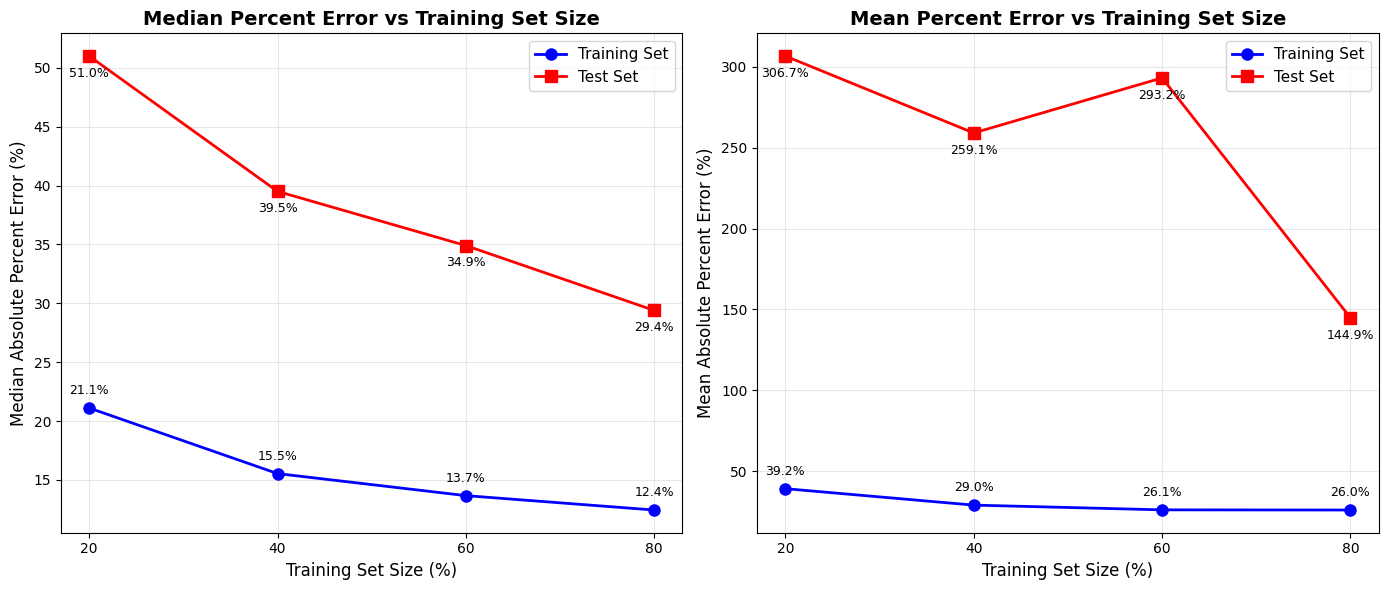


=== SUMMARY TABLE ===
Train%   Test%    Train Samples Test Samples Test R²  Test Median% Test Mean%
--------------------------------------------------------------------------------
   80%      20%        3022.0          756.0      0.635         29.4%       144.9%
   60%      40%        2266.0         1512.0      0.542         34.9%       293.2%
   40%      60%        1511.0         2267.0      0.471         39.5%       259.1%
   20%      80%         755.0         3023.0      0.392         51.0%       306.7%

Analysis complete for bin0_1_thresh0_1_df_spectra


In [12]:
# Loop through different training set sizes and analyze performance
dataset_name = "bin0_1_thresh0_1_df_spectra"
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

print(f"Processing dataset with different training set sizes: {dataset_name}")

# Define training set sizes to test
train_sizes = [0.8, 0.6, 0.4, 0.2]
results_summary = []

try:
    # Load the dataset once
    file_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
    df = pd.read_pickle(file_path)
    
    print(f"Loaded dataset shape: {df.shape}")
    
    # Prepare features and target
    feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
    X = df[feature_cols]
    y = df['log_response']
    
    # Remove rows with NaN values
    valid_mask = ~(X.isna().any(axis=1) | y.isna())
    X_clean = X[valid_mask]
    y_clean = y[valid_mask]
    
    print(f"Clean data shape: X={X_clean.shape}, y={y_clean.shape}")
    
    # Loop through different training set sizes
    for train_size in train_sizes:
        test_size = 1 - train_size
        print(f"\n--- Training with {train_size*100:.0f}% / {test_size*100:.0f}% split ---")
        
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=test_size, random_state=42
        )
        
        print(f"Train/Test split: {X_train.shape[0]} / {X_test.shape[0]} samples")
        
        # Train Random Forest
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
        rf.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        results_summary.append({
            'Train_Size': train_size,
            'Test_Size': test_size,
            'Train_Samples': len(X_train),
            'Test_Samples': len(X_test),
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Train_Median_Error': train_median_percent_error,
            'Test_Median_Error': test_median_percent_error,
            'Train_Mean_Error': train_mean_percent_error,
            'Test_Mean_Error': test_mean_percent_error
        })
        
        # Print results for this split
        print(f"Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
        print(f"Train Median Error: {train_median_percent_error:.1f}%, Test Median Error: {test_median_percent_error:.1f}%")
        print(f"Train Mean Error: {train_mean_percent_error:.1f}%, Test Mean Error: {test_mean_percent_error:.1f}%")

    # Convert results to DataFrame for easier plotting
    results_df = pd.DataFrame(results_summary)
    
    # === SUMMARY PLOTS ===
    
    # 1. Plot showing Median Percent Error vs Training Set Size
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(results_df['Train_Size'] * 100, results_df['Train_Median_Error'], 'o-', 
             linewidth=2, markersize=8, label='Training Set', color='blue')
    plt.plot(results_df['Train_Size'] * 100, results_df['Test_Median_Error'], 's-', 
             linewidth=2, markersize=8, label='Test Set', color='red')
    plt.xlabel('Training Set Size (%)', fontsize=12)
    plt.ylabel('Median Absolute Percent Error (%)', fontsize=12)
    plt.title('Median Percent Error vs Training Set Size', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(results_df['Train_Size'] * 100)
    
    # Add value annotations
    for i, row in results_df.iterrows():
        plt.annotate(f'{row["Train_Median_Error"]:.1f}%', 
                    (row['Train_Size'] * 100, row['Train_Median_Error']), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        plt.annotate(f'{row["Test_Median_Error"]:.1f}%', 
                    (row['Train_Size'] * 100, row['Test_Median_Error']), 
                    textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)
    
    # 2. Plot showing Mean Percent Error vs Training Set Size
    plt.subplot(1, 2, 2)
    plt.plot(results_df['Train_Size'] * 100, results_df['Train_Mean_Error'], 'o-', 
             linewidth=2, markersize=8, label='Training Set', color='blue')
    plt.plot(results_df['Train_Size'] * 100, results_df['Test_Mean_Error'], 's-', 
             linewidth=2, markersize=8, label='Test Set', color='red')
    plt.xlabel('Training Set Size (%)', fontsize=12)
    plt.ylabel('Mean Absolute Percent Error (%)', fontsize=12)
    plt.title('Mean Percent Error vs Training Set Size', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(results_df['Train_Size'] * 100)
    
    # Add value annotations
    for i, row in results_df.iterrows():
        plt.annotate(f'{row["Train_Mean_Error"]:.1f}%', 
                    (row['Train_Size'] * 100, row['Train_Mean_Error']), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        plt.annotate(f'{row["Test_Mean_Error"]:.1f}%', 
                    (row['Train_Size'] * 100, row['Test_Mean_Error']), 
                    textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/RF_TrainingSize_Analysis_{dataset_name}.png", 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary table
    print(f"\n=== SUMMARY TABLE ===")
    print(f"{'Train%':<8} {'Test%':<8} {'Train Samples':<13} {'Test Samples':<12} {'Test R²':<8} {'Test Median%':<12} {'Test Mean%':<10}")
    print("-" * 80)
    for _, row in results_df.iterrows():
        print(f"{row['Train_Size']*100:>5.0f}%   {row['Test_Size']*100:>5.0f}%   "
              f"{row['Train_Samples']:>11}     {row['Test_Samples']:>10}     "
              f"{row['Test_R2']:>6.3f}    {row['Test_Median_Error']:>9.1f}%     "
              f"{row['Test_Mean_Error']:>7.1f}%")
    
    print(f"\nAnalysis complete for {dataset_name}")
    
except Exception as e:
    print(f"Error processing {dataset_name}: {str(e)}")
    import traceback
    traceback.print_exc()

## Spectra RF

In [13]:
# Load datasets folder path
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

# Get all .pkl files in the folder
pkl_files = [f for f in os.listdir(grid_search_folder) if f.endswith('.pkl')]
dataset_names = [f.replace('.pkl', '') for f in pkl_files]

print(f"Found {len(dataset_names)} datasets to process")
print(f"Expected: 182 datasets")

# Verify we have the right count
thresh0_datasets = [name for name in dataset_names if 'thresh_zero' in name]
thresholded_datasets = [name for name in dataset_names if 'thresh_zero' not in name]

print(f"  - Datasets with thresh0 (no threshold): {len(thresh0_datasets)}")
print(f"  - Datasets with thresholds applied: {len(thresholded_datasets)}")

# Initialize storage for results
results_r2 = []
results_percent_error = []

# Dictionary to store individual errors for histogram analysis
saved_spectral_errors = {}

# Process datasets ONE AT A TIME (memory efficient)
for i, dataset_name in enumerate(sorted(dataset_names), 1):
    print(f"Processing {i}/{len(dataset_names)}: {dataset_name}")
    
    try:
        # Load only the current dataset
        file_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Prepare features and target
        feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
        X = df[feature_cols]
        y = df['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.5, random_state=42
        )
        
        # Train Random Forest with limited CPU usage
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
        rf.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Save individual errors for histogram analysis
        saved_spectral_errors[dataset_name] = individual_errors
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue
    
    finally:
        # Always clean up memory after each dataset
        if 'df' in locals():
            del df
        if 'X' in locals():
            del X, y, X_clean, y_clean
        if 'rf' in locals():
            del rf
        gc.collect()
        
        # Periodic deeper cleanup every 20 datasets
        if i % 20 == 0:
            print(f"  Deep cleanup after {i} datasets...")
            gc.collect()

# Convert results to DataFrames
df_r2_results = pd.DataFrame(results_r2)
df_percent_error_results = pd.DataFrame(results_percent_error)

print(f"\nCompleted! Processed {len(results_r2)} datasets successfully.")
print(f"Saved individual errors for {len(saved_spectral_errors)} datasets")
print(f"Results stored in: df_r2_results, df_percent_error_results")

Found 169 datasets to process
Expected: 182 datasets
  - Datasets with thresh0 (no threshold): 13
  - Datasets with thresholds applied: 156
Processing 1/169: bin0_05_thresh0_001_df_spectra
Completed: Test R² = 0.5512, Test Median % Error = 33.8%
Processing 2/169: bin0_05_thresh0_005_df_spectra
Completed: Test R² = 0.5486, Test Median % Error = 33.7%
Processing 3/169: bin0_05_thresh0_01_df_spectra
Completed: Test R² = 0.5478, Test Median % Error = 34.0%
Processing 4/169: bin0_05_thresh0_05_df_spectra
Completed: Test R² = 0.5513, Test Median % Error = 33.7%
Processing 5/169: bin0_05_thresh0_1_df_spectra
Completed: Test R² = 0.5509, Test Median % Error = 33.0%
Processing 6/169: bin0_05_thresh0_5_df_spectra
Completed: Test R² = 0.5454, Test Median % Error = 34.5%
Processing 7/169: bin0_05_thresh100_df_spectra
Completed: Test R² = -0.0004, Test Median % Error = 68.9%
Processing 8/169: bin0_05_thresh10_df_spectra
Completed: Test R² = 0.4728, Test Median % Error = 32.2%
Processing 9/169: bin0

## Spectra Heatmap

Checking for duplicates in results...
Original df_r2_results shape: (169, 7)
After removing duplicates: (169, 7)
Creating detailed heatmaps...


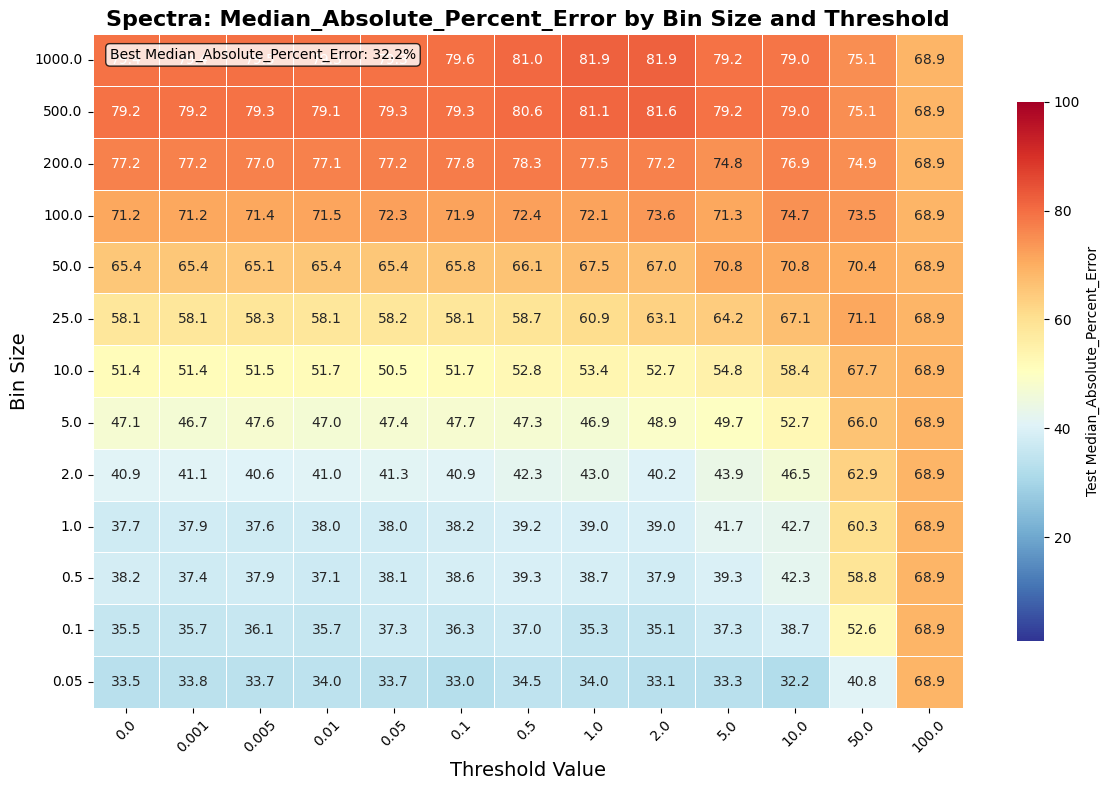

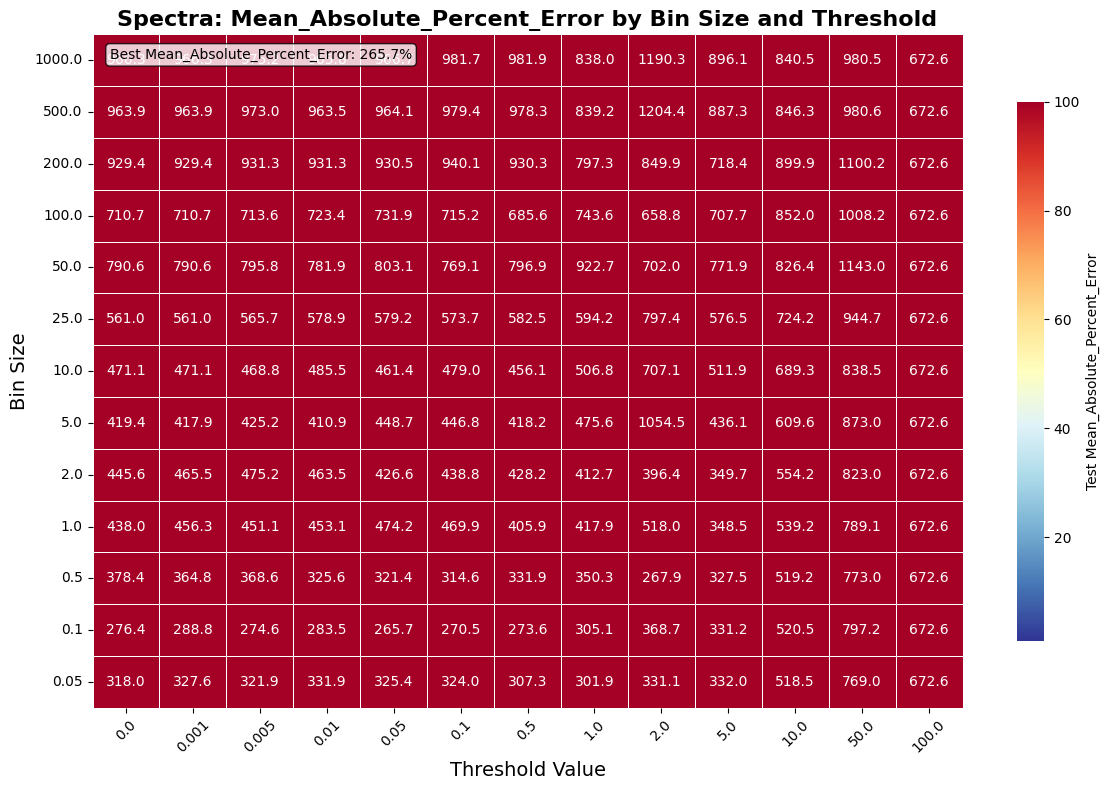

In [14]:
# Create the actual heatmaps for visualization
# First, let's extract bin size and threshold from the dataset names and add to results
def parse_dataset_name(dataset_name):
    """Extract bin size and threshold from dataset name"""
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in dataset_name:
        # Extract bin size
        bin_part = dataset_name.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = dataset_name.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to results DataFrames
for df_results in [df_r2_results, df_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in results...")
print(f"Original df_r2_results shape: {df_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_r2_results = df_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_percent_error_results = df_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_r2_results.shape}")

# Now create pivot tables 
r2_pivot = df_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
median_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
mean_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
r2_pivot = r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
median_percent_error_pivot = median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
mean_percent_error_pivot = mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Also create individual larger heatmaps for better detail
def create_detailed_heatmap_spec(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'Spectra: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/Spectra_{metric_name}_by_Bin_Size_and_Threshold")
    plt.show()

# Create detailed individual heatmaps
print("Creating detailed heatmaps...")

# create_detailed_heatmap_spec(r2_pivot, 'R²', 'RdYlBu')     
create_detailed_heatmap_spec(median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_spec(mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

# ChemNet RF and Heatmap

## ChemNet RF

In [15]:
import os
import gc
import pickle

# Load ChemNet datasets folder path
chemnet_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"

# Get all .pkl files in the folder
chemnet_pkl_files = [f for f in os.listdir(chemnet_folder) if f.endswith('.pkl')]
chemnet_dataset_names = [f.replace('.pkl', '') for f in chemnet_pkl_files]

print(f"Found {len(chemnet_dataset_names)} ChemNet datasets to process")

# Verify we have the right count
chemnet_thresh0_datasets = [name for name in chemnet_dataset_names if 'thresh_zero' in name]
chemnet_thresholded_datasets = [name for name in chemnet_dataset_names if 'thresh_zero' not in name]

print(f"  - ChemNet datasets with thresh0 (no threshold): {len(chemnet_thresh0_datasets)}")
print(f"  - ChemNet datasets with thresholds applied: {len(chemnet_thresholded_datasets)}")

# Initialize storage for ChemNet results
chemnet_results_r2 = []
chemnet_results_percent_error = []

# Dictionary to store individual errors for histogram analysis
saved_chemnet_errors = {}

# Process ChemNet datasets ONE AT A TIME (memory efficient)
for i, dataset_name in enumerate(sorted(chemnet_dataset_names), 1):
    print(f"Processing {i}/{len(chemnet_dataset_names)}: {dataset_name}")
    
    try:
        # Load only the current ChemNet dataset
        file_path = os.path.join(chemnet_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Prepare features and target (embedding columns are the features)
        feature_cols = [col for col in df.columns if col.startswith('emb_')]
        X = df[feature_cols]
        y = df['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.50, random_state=47
        )
        
        # Train Random Forest with limited CPU usage
        rf_chemnet = RandomForestRegressor(n_estimators=100, random_state=47, n_jobs=2)
        rf_chemnet.fit(X_train, y_train)

        # Make predictions
        y_train_pred = rf_chemnet.predict(X_train)
        y_test_pred = rf_chemnet.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Save individual errors for histogram analysis
        saved_chemnet_errors[dataset_name] = individual_errors
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        chemnet_results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        chemnet_results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue
    
    finally:
        # Always clean up memory after each dataset
        if 'df' in locals():
            del df
        if 'X' in locals():
            del X, y, X_clean, y_clean
        if 'rf_chemnet' in locals():
            del rf_chemnet
        gc.collect()
        
        # Periodic deeper cleanup every 20 datasets
        if i % 20 == 0:
            print(f"  Deep cleanup after {i} datasets...")
            gc.collect()

# Convert results to DataFrames
df_chemnet_r2_results = pd.DataFrame(chemnet_results_r2)
df_chemnet_percent_error_results = pd.DataFrame(chemnet_results_percent_error)

print(f"\nCompleted! Processed {len(chemnet_results_r2)} ChemNet datasets successfully.")
print(f"Saved individual errors for {len(saved_chemnet_errors)} datasets")
print(f"Results stored in: df_chemnet_r2_results, df_chemnet_percent_error_results")

# Display summary statistics
print("\n=== CHEMNET SUMMARY STATISTICS ===")
print("Test R² Statistics:")
print(df_chemnet_r2_results['Test_R2'].describe())

print("\nTest Median Percent Error Statistics:")
print(df_chemnet_percent_error_results['Test_Median_Percent_Error'].describe())

print("\nTest Mean Percent Error Statistics:")
print(df_chemnet_percent_error_results['Test_Mean_Percent_Error'].describe())

# Show top 10 performing ChemNet datasets by Test R²
print("\n=== TOP 10 CHEMNET DATASETS BY TEST R² ===")
top_chemnet_r2 = df_chemnet_r2_results.nlargest(10, 'Test_R2')[['Dataset', 'Test_R2', 'Features']]
print(top_chemnet_r2.to_string(index=False))

# Show comparison between thresh0 (no threshold) and thresholded ChemNet datasets
print("\n=== CHEMNET THRESH0 vs THRESHOLDED COMPARISON ===")
chemnet_thresh0_results = df_chemnet_r2_results[df_chemnet_r2_results['Dataset'].str.contains('thresh_zero')]
chemnet_thresholded_results = df_chemnet_r2_results[~df_chemnet_r2_results['Dataset'].str.contains('thresh_zero')]

if len(chemnet_thresh0_results) > 0:
    print(f"ChemNet thresh0 datasets (no threshold) - Mean Test R²: {chemnet_thresh0_results['Test_R2'].mean():.4f}")
    print(f"Best ChemNet thresh0 dataset: {chemnet_thresh0_results.loc[chemnet_thresh0_results['Test_R2'].idxmax(), 'Dataset']} (R² = {chemnet_thresh0_results['Test_R2'].max():.4f})")

if len(chemnet_thresholded_results) > 0:
    print(f"ChemNet thresholded datasets - Mean Test R²: {chemnet_thresholded_results['Test_R2'].mean():.4f}")
    print(f"Best ChemNet thresholded dataset: {chemnet_thresholded_results.loc[chemnet_thresholded_results['Test_R2'].idxmax(), 'Dataset']} (R² = {chemnet_thresholded_results['Test_R2'].max():.4f})")

Found 169 ChemNet datasets to process
  - ChemNet datasets with thresh0 (no threshold): 13
  - ChemNet datasets with thresholds applied: 156
Processing 1/169: chemnet_emb_bin0_05_thresh0_001_df_spectra


Completed: Test R² = 0.8816, Test Median % Error = 13.1%
Processing 2/169: chemnet_emb_bin0_05_thresh0_005_df_spectra
Completed: Test R² = 0.8659, Test Median % Error = 18.7%
Processing 3/169: chemnet_emb_bin0_05_thresh0_01_df_spectra
Completed: Test R² = 0.9184, Test Median % Error = 9.2%
Processing 4/169: chemnet_emb_bin0_05_thresh0_05_df_spectra
Completed: Test R² = 0.8587, Test Median % Error = 17.6%
Processing 5/169: chemnet_emb_bin0_05_thresh0_1_df_spectra
Completed: Test R² = 0.8686, Test Median % Error = 15.4%
Processing 6/169: chemnet_emb_bin0_05_thresh0_5_df_spectra
Completed: Test R² = 0.8702, Test Median % Error = 14.8%
Processing 7/169: chemnet_emb_bin0_05_thresh100_df_spectra
Completed: Test R² = 1.0000, Test Median % Error = 0.0%
Processing 8/169: chemnet_emb_bin0_05_thresh10_df_spectra
Completed: Test R² = 0.8761, Test Median % Error = 13.3%
Processing 9/169: chemnet_emb_bin0_05_thresh1_df_spectra
Completed: Test R² = 0.8630, Test Median % Error = 14.7%
Processing 10/16

## ChemNet Heatmap

Checking for duplicates in ChemNet results...
Original df_chemnet_r2_results shape: (169, 7)
After removing duplicates: (169, 7)
Creating detailed ChemNet heatmaps...


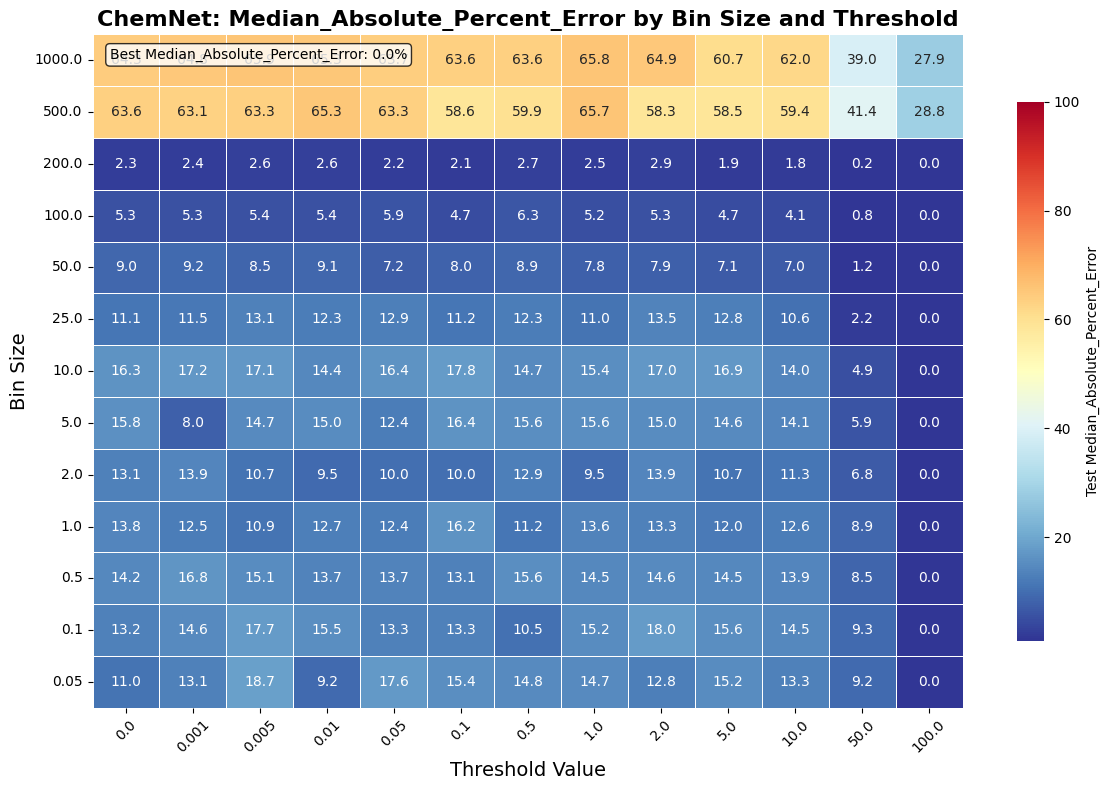

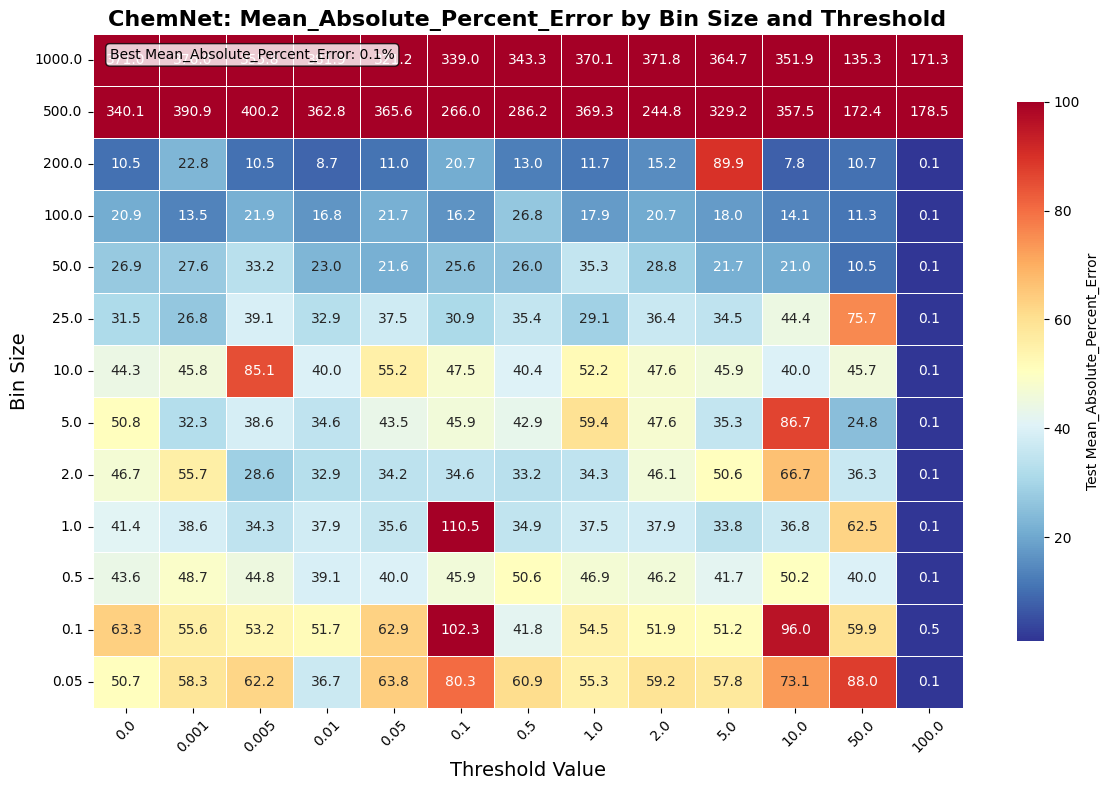

In [16]:
# Create the actual heatmaps for ChemNet visualization
# First, let's extract bin size and threshold from the ChemNet dataset names and add to results
def parse_chemnet_dataset_name(dataset_name):
    """Extract bin size and threshold from ChemNet dataset name"""
    # Remove 'chemnet_emb_' prefix
    name_part = dataset_name.replace('chemnet_emb_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to ChemNet results DataFrames
for df_results in [df_chemnet_r2_results, df_chemnet_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_chemnet_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in ChemNet results...")
print(f"Original df_chemnet_r2_results shape: {df_chemnet_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_chemnet_r2_results = df_chemnet_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_chemnet_percent_error_results = df_chemnet_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_chemnet_r2_results.shape}")

# Now create pivot tables for ChemNet
chemnet_r2_pivot = df_chemnet_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
chemnet_median_percent_error_pivot = df_chemnet_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
chemnet_mean_percent_error_pivot = df_chemnet_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50,100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000] # 0.05, 0.1,

# Reindex pivot tables to show all columns, filling missing with NaN
chemnet_r2_pivot = chemnet_r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
chemnet_median_percent_error_pivot = chemnet_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
chemnet_mean_percent_error_pivot = chemnet_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)


# Also create individual larger heatmaps for ChemNet for better detail
def create_detailed_heatmap_chemnet(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single ChemNet metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'ChemNet: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/ChemNet_{metric_name}_by_Bin_Size_and_Threshold")

    plt.show()

# Create detailed individual ChemNet heatmaps
print("Creating detailed ChemNet heatmaps...")

# create_detailed_heatmap_chemnet(chemnet_r2_pivot, 'R²', 'RdYlBu')     
create_detailed_heatmap_chemnet(chemnet_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_chemnet(chemnet_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

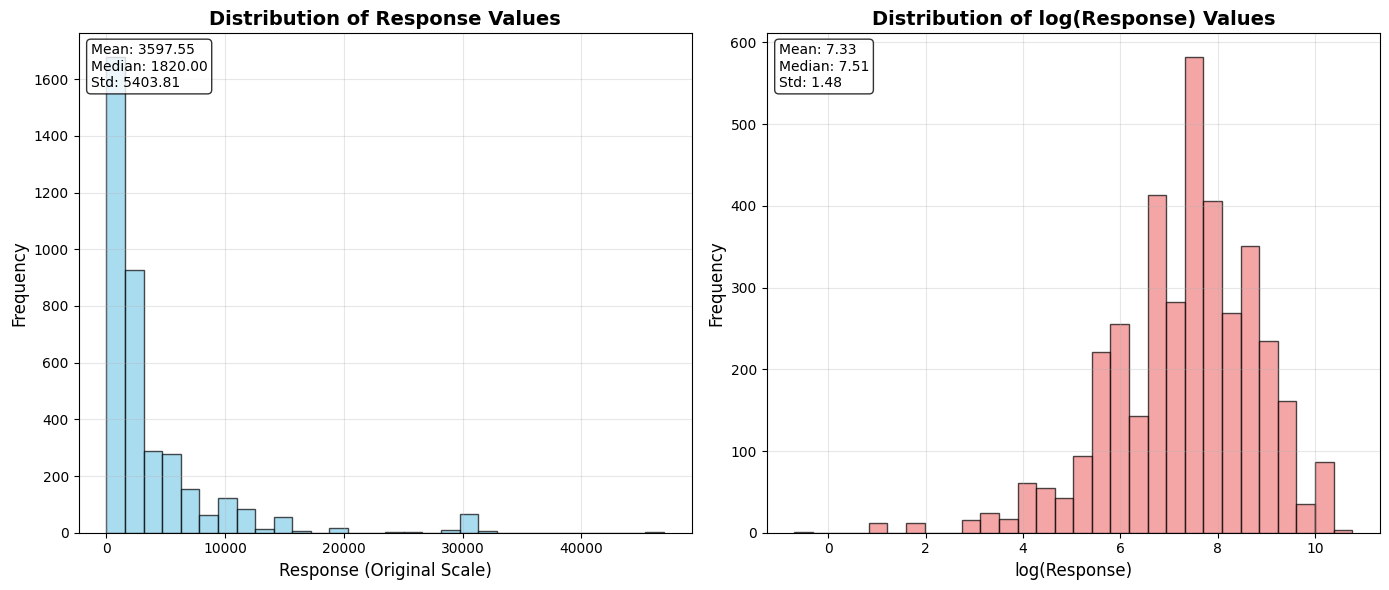

=== RESPONSE DISTRIBUTION SUMMARY ===
Total samples: 3778
Unique SMILES: 485

Response (Original Scale) Statistics:
count     3778.000000
mean      3597.547252
std       5403.805559
min          0.500000
25%        685.000000
50%       1820.000000
75%       4073.000000
max      46965.463940
Name: Response, dtype: float64

log(Response) Statistics:
count    3778.000000
mean        7.326832
std         1.483582
min        -0.693147
25%         6.529419
50%         7.506592
75%         8.312135
max        10.757168
Name: log_response, dtype: float64

Response range: 0.50 to 46965.46
log(Response) range: -0.69 to 10.76


In [17]:
# Load the df5_subset data
df5_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_subset.parquet')

# Create log_response column if it doesn't exist
if 'log_response' not in df5_subset.columns:
    df5_subset['log_response'] = np.log(df5_subset['Response'])

# Create figure with two subplots
plt.figure(figsize=(14, 6))

# Subplot 1: Response values (original scale)
plt.subplot(1, 2, 1)
plt.hist(df5_subset['Response'], bins=30, alpha=0.7, edgecolor='black', color='skyblue')
plt.xlabel('Response (Original Scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Response Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add statistics annotation
response_mean = df5_subset['Response'].mean()
response_median = df5_subset['Response'].median()
response_std = df5_subset['Response'].std()
plt.text(0.02, 0.98, f'Mean: {response_mean:.2f}\nMedian: {response_median:.2f}\nStd: {response_std:.2f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='top', fontsize=10)

# Subplot 2: log_response values (log scale)
plt.subplot(1, 2, 2)
plt.hist(df5_subset['log_response'], bins=30, alpha=0.7, edgecolor='black', color='lightcoral')
plt.xlabel('log(Response)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of log(Response) Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add statistics annotation
log_response_mean = df5_subset['log_response'].mean()
log_response_median = df5_subset['log_response'].median()
log_response_std = df5_subset['log_response'].std()
plt.text(0.02, 0.98, f'Mean: {log_response_mean:.2f}\nMedian: {log_response_median:.2f}\nStd: {log_response_std:.2f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='top', fontsize=10)

plt.tight_layout()
plt.savefig('/home/dlipsey/MITLincolnLabs/Figures/Response_Distribution_Histograms.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("=== RESPONSE DISTRIBUTION SUMMARY ===")
print(f"Total samples: {len(df5_subset)}")
print(f"Unique SMILES: {df5_subset['SMILES_spectra'].nunique()}")
print("\nResponse (Original Scale) Statistics:")
print(df5_subset['Response'].describe())
print("\nlog(Response) Statistics:")
print(df5_subset['log_response'].describe())
print(f"\nResponse range: {df5_subset['Response'].min():.2f} to {df5_subset['Response'].max():.2f}")
print(f"log(Response) range: {df5_subset['log_response'].min():.2f} to {df5_subset['log_response'].max():.2f}")

In [18]:
# ========== SUPER TEST SET SELECTION ==========
# SMILES selected to cover a wide range of response values, each with 4+ spectra

# Load the main dataset
df5_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_subset.parquet')

print(f"Total dataset shape: {df5_subset.shape}")
print(f"Unique SMILES: {df5_subset['SMILES_spectra'].nunique()}")

# Count how many spectra each SMILES has
smiles_counts = df5_subset['SMILES_spectra'].value_counts()
smiles_with_4plus = smiles_counts[smiles_counts >= 4].index.tolist()

print(f"SMILES with 4+ spectra: {len(smiles_with_4plus)}")

# Filter dataset to only include SMILES with 4+ examples
df_filtered = df5_subset[df5_subset['SMILES_spectra'].isin(smiles_with_4plus)]

# Get unique SMILES with their response values (take first occurrence)
unique_smiles_responses = df_filtered.drop_duplicates(subset=['SMILES_spectra'])[['SMILES_spectra', 'Response']]

print(f"Unique SMILES with 4+ spectra: {len(unique_smiles_responses)}")

# Define response value ranges and target counts
response_ranges = [
    (0, 5, 1, "< 5"),
    (5, 50, 1, "5-50"), 
    (50, 500, 3, "50-500"),
    (500, 1000, 3, "500-1000"),
    (1000, 2000, 1, "1000-2000"),
    (2000, 5000, 1, "2000-5000")
]

selected_smiles = []
selection_details = []

# Select SMILES for each range
for min_val, max_val, count_needed, range_label in response_ranges:
    # Find SMILES in this response range
    range_mask = (unique_smiles_responses['Response'] >= min_val) & (unique_smiles_responses['Response'] < max_val)
    candidates = unique_smiles_responses[range_mask]
    
    print(f"\nRange {range_label}: Found {len(candidates)} candidates")
    
    if len(candidates) >= count_needed:
        # Randomly sample the required number
        selected = candidates.sample(n=count_needed, random_state=42)
        
        for _, row in selected.iterrows():
            smiles = row['SMILES_spectra']
            response = row['Response']
            count = smiles_counts[smiles]
            
            selected_smiles.append(smiles)
            selection_details.append({
                'SMILES': smiles,
                'Response': response,
                'Range': range_label,
                'Spectra_Count': count
            })
            
            print(f"  Selected: {smiles[:50]}... (Response: {response:.2f}, Count: {count})")
    else:
        print(f"  ⚠️  WARNING: Only {len(candidates)} candidates found, need {count_needed}")
        # Take all available candidates
        for _, row in candidates.iterrows():
            smiles = row['SMILES_spectra']
            response = row['Response']
            count = smiles_counts[smiles]
            
            selected_smiles.append(smiles)
            selection_details.append({
                'SMILES': smiles,
                'Response': response,
                'Range': range_label,
                'Spectra_Count': count
            })
            
            print(f"  Selected: {smiles[:50]}... (Response: {response:.2f}, Count: {count})")

# Convert to DataFrame for easy viewing
selection_df = pd.DataFrame(selection_details)

print(f"\n=== FINAL SELECTION SUMMARY ===")
print(f"Total SMILES selected: {len(selected_smiles)}")
print("\nDetailed breakdown:")
print(selection_df.to_string(index=False))

# Show distribution across ranges
print(f"\n=== SELECTION BY RANGE ===")
range_summary = selection_df.groupby('Range').agg({
    'SMILES': 'count',
    'Response': ['min', 'max', 'mean'],
    'Spectra_Count': ['min', 'max', 'mean']
}).round(2)
print(range_summary)

# Verify each selected SMILES has 4+ spectra
print(f"\n=== VERIFICATION ===")
all_have_4plus = all(selection_df['Spectra_Count'] >= 4)
print(f"All selected SMILES have 4+ spectra: {all_have_4plus}")

# Show the final list of SMILES
print(f"\n=== FINAL SMILES LIST ===")
for i, smiles in enumerate(selected_smiles, 1):
    details = selection_df[selection_df['SMILES'] == smiles].iloc[0]
    print(f"{i:2d}. {smiles}")
    print(f"    Response: {details['Response']:.2f}, Range: {details['Range']}, Count: {details['Spectra_Count']}")

# Save the selection for future use
selected_smiles_info = {
    'smiles_list': selected_smiles,
    'details_df': selection_df,
    'selection_criteria': {
        'min_spectra_count': 4,
        'ranges': response_ranges,
        'total_selected': len(selected_smiles)
    }
}

# You can save this to a file if needed
# import pickle
# with open('/home/dlipsey/MITLincolnLabs/MIT_LL_data/selected_smiles_analysis.pkl', 'wb') as f:
#     pickle.dump(selected_smiles_info, f)

print(f"\n=== RESPONSE DISTRIBUTION CHECK ===")
print(f"Selected Response range: {selection_df['Response'].min():.2f} to {selection_df['Response'].max():.2f}")
print(f"log(Response) range: {np.log(selection_df['Response']).min():.2f} to {np.log(selection_df['Response']).max():.2f}")

Total dataset shape: (3778, 18)
Unique SMILES: 485
SMILES with 4+ spectra: 391
Unique SMILES with 4+ spectra: 391

Range < 5: Found 2 candidates
  Selected: NC(=S)Nc1ccccc1... (Response: 3.00, Count: 6)

Range 5-50: Found 9 candidates
  Selected: COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1... (Response: 7.21, Count: 12)

Range 50-500: Found 70 candidates
  Selected: CCNc1nc(Cl)nc(NC(C)(C)C#N)n1... (Response: 218.50, Count: 6)
  Selected: C#CCN(C)Cc1ccccc1... (Response: 273.64, Count: 6)
  Selected: COP(=S)(OC)Oc1ccc(SC)c(C)c1... (Response: 180.00, Count: 6)

Range 500-1000: Found 44 candidates
  Selected: Nc1cccc2c(N)cccc12... (Response: 634.00, Count: 6)
  Selected: Cn1c(=O)c2c(ncn2CCO)n(C)c1=O... (Response: 710.00, Count: 40)
  Selected: CNC(=O)N(C)c1nnc(C(C)(C)C)s1... (Response: 642.00, Count: 6)

Range 1000-2000: Found 85 candidates
  Selected: Nc1ccc(Sc2ccc(N)cc2)cc1... (Response: 1000.00, Count: 15)

Range 2000-5000: Found 108 candidates
  Selected: COc1ccc2ccc(=O)oc2c1CC=C(C)

# Spectra Supter Test Set RF

In [19]:
# And her is an example list of SMILES for the super test set, with counts commented out on their lines:
super_test_smiles = [
    'NC(=S)Nc1ccccc1',                                  # 6
    'COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1',   # 12
    'CCNc1nc(Cl)nc(NC(C)(C)C#N)n1',                     # 6 
    'C#CCN(C)Cc1ccccc1',                                # 6
    'COP(=S)(OC)Oc1ccc(SC)c(C)c1',                      # 6
    'Nc1cccc2c(N)cccc12',                               # 6
    'Cn1c(=O)c2c(ncn2CCO)n(C)c1=O',                     # 40
    'CNC(=O)N(C)c1nnc(C(C)(C)C)s1',                     # 6
    'Nc1ccc(Sc2ccc(N)cc2)cc1',                          # 15
    'COc1ccc2ccc(=O)oc2c1CC=C(C)C',                     # 6
]

In [20]:
# === CONFIGURABLE PARAMETERS ===
dataset_name = "bin0_1_thresh100_df_spectra"  # Change this to any dataset you want
folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"  # Change folder path here

# Super test set SMILES to remove (comment out these lines to include them)
super_test_smiles = [
    'NC(=S)Nc1ccccc1',                                  # 6
    'COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1',   # 12
    'CCNc1nc(Cl)nc(NC(C)(C)C#N)n1',                     # 6 
    'C#CCN(C)Cc1ccccc1',                                # 6
    'COP(=S)(OC)Oc1ccc(SC)c(C)c1',                      # 6
    'Nc1cccc2c(N)cccc12',                               # 6
    'Cn1c(=O)c2c(ncn2CCO)n(C)c1=O',                     # 40
    'CNC(=O)N(C)c1nnc(C(C)(C)C)s1',                     # 6
    'Nc1ccc(Sc2ccc(N)cc2)cc1',                          # 15
    'COc1ccc2ccc(=O)oc2c1CC=C(C)C',                     # 6
]

print(f"Dataset: {dataset_name}")

# === LOAD AND PROCESS DATASET ===
file_path = os.path.join(folder, f"{dataset_name}.pkl")
df = pd.read_pickle(file_path)

print(f"Loaded dataset shape: {df.shape}")

# === REMOVE SUPER TEST SET (COMMENT OUT TO INCLUDE) ===
# Remove super test set SMILES from training data
original_count = len(df)
df = df[~df['SMILES_spectra'].isin(super_test_smiles)]
removed_count = original_count - len(df)
print(f"Removed {removed_count} samples from super test set")
print(f"Dataset shape after removal: {df.shape}")

# Prepare features and target
feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
X = df[feature_cols]
y = df['log_response']

# Check for NaN values - BREAK if any are found
if X.isna().any().any():
    nan_cols = X.columns[X.isna().any()].tolist()
    raise ValueError(f"Found NaN values in feature columns: {nan_cols}")

if y.isna().any():
    raise ValueError("Found NaN values in target variable 'log_response'")

print(f"Data shape: X={X.shape}, y={y.shape}")

# === TRAIN RANDOM FOREST ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
rf.fit(X_train, y_train)

# Make predictions
y_test_pred = rf.predict(X_test)

# Calculate percent errors (undo log transform)
y_test_true_response = np.exp(y_test)
y_test_pred_response = np.exp(y_test_pred)
individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100

test_median_percent_error = np.median(individual_errors)
test_mean_percent_error = np.mean(individual_errors)

# === RESULTS ===
print(f"\nTest Median % Error: {test_median_percent_error:.1f}%")
print(f"Test Mean % Error: {test_mean_percent_error:.1f}%")

Dataset: bin0_1_thresh100_df_spectra
Loaded dataset shape: (3778, 11618)
Removed 109 samples from super test set
Dataset shape after removal: (3669, 11618)
Data shape: X=(3669, 11616), y=(3669,)

Test Median % Error: 68.1%
Test Mean % Error: 402.4%


In [21]:
# === SUPER TEST SET EVALUATION ===
# Super test set SMILES
super_test_smiles = [
    'NC(=S)Nc1ccccc1',                                  # 6
    'COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1',   # 12
    'CCNc1nc(Cl)nc(NC(C)(C)C#N)n1',                     # 6 
    'C#CCN(C)Cc1ccccc1',                                # 6
    'COP(=S)(OC)Oc1ccc(SC)c(C)c1',                      # 6
    'Nc1cccc2c(N)cccc12',                               # 6
    'Cn1c(=O)c2c(ncn2CCO)n(C)c1=O',                     # 40
    'CNC(=O)N(C)c1nnc(C(C)(C)C)s1',                     # 6
    'Nc1ccc(Sc2ccc(N)cc2)cc1',                          # 15
    'COc1ccc2ccc(=O)oc2c1CC=C(C)C',                     # 6
]

# Load the full dataset (including super test set)
file_path = os.path.join(folder, f"{dataset_name}.pkl")
df_full = pd.read_pickle(file_path)

# Extract super test set
super_test_df = df_full[df_full['SMILES_spectra'].isin(super_test_smiles)]

print(f"Super test set size: {len(super_test_df)} samples")
print(f"Super test SMILES found: {super_test_df['SMILES_spectra'].nunique()} unique SMILES")

# Prepare super test features and targets
feature_cols = [col for col in super_test_df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
X_super_test = super_test_df[feature_cols]
y_super_test = super_test_df['log_response']

# Make predictions on super test set using the trained model (rf)
y_super_test_pred = rf.predict(X_super_test)

# Calculate percent errors (undo log transform)
y_super_test_true_response = np.exp(y_super_test)
y_super_test_pred_response = np.exp(y_super_test_pred)
super_test_individual_errors = np.abs((y_super_test_pred_response - y_super_test_true_response) / y_super_test_true_response) * 100

super_test_median_percent_error = np.median(super_test_individual_errors)
super_test_mean_percent_error = np.mean(super_test_individual_errors)

# === RESULTS ===
print(f"\n=== SUPER TEST SET RESULTS ===")
print(f"Super Test Median % Error: {super_test_median_percent_error:.1f}%")
print(f"Super Test Mean % Error: {super_test_mean_percent_error:.1f}%")

# === DETAILED BREAKDOWN BY SMILES ===
print(f"\n=== DETAILED BREAKDOWN BY SMILES ===")
super_test_df_with_pred = super_test_df.copy()
super_test_df_with_pred['Predicted_log_response'] = y_super_test_pred
super_test_df_with_pred['Predicted_Response'] = y_super_test_pred_response
super_test_df_with_pred['Individual_Error'] = super_test_individual_errors

# Group by SMILES and calculate statistics
smiles_stats = super_test_df_with_pred.groupby('SMILES_spectra').agg({
    'Response': ['count', 'mean'],
    'Individual_Error': ['mean', 'median']
}).round(1)

smiles_stats.columns = ['Count', 'True_Response_Mean', 'Mean_Error', 'Median_Error']
smiles_stats = smiles_stats.reset_index()

print(f"{'SMILES':<50} {'Count':<6} {'True_Resp':<10} {'Mean_Err':<9} {'Med_Err':<8}")
print("-" * 85)
for _, row in smiles_stats.iterrows():
    smiles_short = row['SMILES_spectra'][:45] + "..." if len(row['SMILES_spectra']) > 45 else row['SMILES_spectra']
    print(f"{smiles_short:<50} {row['Count']:<6.0f} {row['True_Response_Mean']:<10.1f} {row['Mean_Error']:<9.1f}% {row['Median_Error']:<8.1f}%")

Super test set size: 109 samples
Super test SMILES found: 10 unique SMILES

=== SUPER TEST SET RESULTS ===
Super Test Median % Error: 125.0%
Super Test Mean % Error: 5530.9%

=== DETAILED BREAKDOWN BY SMILES ===
SMILES                                             Count  True_Resp  Mean_Err  Med_Err 
-------------------------------------------------------------------------------------
C#CCN(C)Cc1ccccc1                                  6      273.6      483.7    % 483.7   %
CCNc1nc(Cl)nc(NC(C)(C)C#N)n1                       6      218.5      631.0    % 631.0   %
CNC(=O)N(C)c1nnc(C(C)(C)C)s1                       6      642.0      148.8    % 148.8   %
COP(=S)(OC)Oc1ccc(SC)c(C)c1                        6      180.0      787.4    % 787.4   %
COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc...   12     7.2        22053.1  % 22053.1 %
COc1ccc2ccc(=O)oc2c1CC=C(C)C                       6      2905.0     45.0     % 45.0    %
Cn1c(=O)c2c(ncn2CCO)n(C)c1=O                       40     710.0      125.0

# ChemNet Super Test Set RF

In [22]:
# View the dataframe head
dataset_name = "chemnet_emb_bin0_1_thresh0_1_df_spectra"  # Change this to any dataset you want
folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"  # Change folder path here

df = pd.read_pickle(os.path.join(folder, f"{dataset_name}.pkl"))
df.head()

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511,SMILES_spectra,Response,log_response,index_id
0,-0.138372,-0.028126,-0.470714,0.355514,-0.192495,0.051052,-0.484355,-0.271956,-0.321912,0.206045,...,-0.426817,-0.102536,-0.334953,-0.600846,0.266666,-0.107150,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,213
1,-0.170064,0.009710,-0.455615,0.368871,-0.184370,0.027258,-0.474222,-0.266902,-0.319529,0.211004,...,-0.456274,-0.095278,-0.299249,-0.596987,0.280877,-0.056583,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,211
2,-0.152057,0.006864,-0.479647,0.332515,-0.185182,0.032891,-0.484368,-0.268179,-0.311028,0.219464,...,-0.456219,-0.089106,-0.313846,-0.622469,0.262479,-0.085211,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,214
3,0.305195,-0.009654,-0.202481,0.148799,-0.190394,0.079215,0.515682,-0.250115,-0.309730,0.429917,...,-0.061100,-0.086916,-0.455637,0.134329,0.139420,0.126727,C#CCOC(=O)[C@@H](C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,2125.857143,7.661930,2958
4,0.209256,-0.023982,-0.130968,0.044996,-0.272925,0.062253,0.499890,-0.227606,-0.309961,0.457334,...,-0.008089,-0.098894,-0.473902,0.231832,0.131747,0.040932,C#CCOC(=O)[C@@H](C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,2125.857143,7.661930,2961


In [23]:
# === CONFIGURABLE PARAMETERS ===
dataset_name = "chemnet_emb_bin1_thresh100_df_spectra"  # Bin: 0.1, Thresh: 100
folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"  # ChemNet folder path

# Super test set SMILES to remove (comment out these lines to include them)
super_test_smiles = [
    'NC(=S)Nc1ccccc1',                                  # 6
    'COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1',   # 12
    'CCNc1nc(Cl)nc(NC(C)(C)C#N)n1',                     # 6 
    'C#CCN(C)Cc1ccccc1',                                # 6
    'COP(=S)(OC)Oc1ccc(SC)c(C)c1',                      # 6
    'Nc1cccc2c(N)cccc12',                               # 6
    'Cn1c(=O)c2c(ncn2CCO)n(C)c1=O',                     # 40
    'CNC(=O)N(C)c1nnc(C(C)(C)C)s1',                     # 6
    'Nc1ccc(Sc2ccc(N)cc2)cc1',                          # 15
    'COc1ccc2ccc(=O)oc2c1CC=C(C)C',                     # 6
]

print(f"Dataset: {dataset_name}")

# === LOAD AND PROCESS DATASET ===
file_path = os.path.join(folder, f"{dataset_name}.pkl")
df = pd.read_pickle(file_path)

print(f"Loaded dataset shape: {df.shape}")

# === REMOVE SUPER TEST SET (COMMENT OUT TO INCLUDE) ===
# Remove super test set SMILES from training data
original_count = len(df)
df = df[~df['SMILES_spectra'].isin(super_test_smiles)]
removed_count = original_count - len(df)
print(f"Removed {removed_count} samples from super test set")
print(f"Dataset shape after removal: {df.shape}")

# Prepare features and target (ChemNet embeddings start with 'emb_')
feature_cols = [col for col in df.columns if col.startswith('emb_')]
X = df[feature_cols]
y = df['log_response']

# Check for NaN values - BREAK if any are found
if X.isna().any().any():
    nan_cols = X.columns[X.isna().any()].tolist()
    raise ValueError(f"Found NaN values in feature columns: {nan_cols}")

if y.isna().any():
    raise ValueError("Found NaN values in target variable 'log_response'")

print(f"Data shape: X={X.shape}, y={y.shape}")
print(f"Number of embedding features: {len(feature_cols)}")

# === TRAIN RANDOM FOREST ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
rf.fit(X_train, y_train)

# Make predictions
y_test_pred = rf.predict(X_test)

# Calculate percent errors (undo log transform)
y_test_true_response = np.exp(y_test)
y_test_pred_response = np.exp(y_test_pred)
individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100

test_median_percent_error = np.median(individual_errors)
test_mean_percent_error = np.mean(individual_errors)

# === RESULTS ===
print(f"\nTest Median % Error: {test_median_percent_error:.1f}%")
print(f"Test Mean % Error: {test_mean_percent_error:.1f}%")

Dataset: chemnet_emb_bin1_thresh100_df_spectra
Loaded dataset shape: (3514, 516)
Removed 0 samples from super test set
Dataset shape after removal: (3514, 516)
Data shape: X=(3514, 512), y=(3514,)
Number of embedding features: 512



Test Median % Error: 0.0%
Test Mean % Error: 0.1%


In [24]:
# === SUPER TEST SET EVALUATION ===
# === CONFIGURABLE PARAMETERS ===
dataset_name = "super_test_chemnet_emb_bin1_thresh100_df_spectra"  
folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/super_test_sets"  

# Super test set SMILES
super_test_smiles = [
    'NC(=S)Nc1ccccc1',                                  # 6
    'COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1',   # 12
    'CCNc1nc(Cl)nc(NC(C)(C)C#N)n1',                     # 6 
    'C#CCN(C)Cc1ccccc1',                                # 6
    'COP(=S)(OC)Oc1ccc(SC)c(C)c1',                      # 6
    'Nc1cccc2c(N)cccc12',                               # 6
    'Cn1c(=O)c2c(ncn2CCO)n(C)c1=O',                     # 40
    'CNC(=O)N(C)c1nnc(C(C)(C)C)s1',                     # 6
    'Nc1ccc(Sc2ccc(N)cc2)cc1',                          # 15
    'COc1ccc2ccc(=O)oc2c1CC=C(C)C',                     # 6
]

# Load the full dataset (including super test set)
file_path = os.path.join(folder, f"{dataset_name}.pkl")
df_full = pd.read_pickle(file_path)

# Extract super test set
super_test_df = df_full[df_full['SMILES_spectra'].isin(super_test_smiles)]

print(f"Super test set size: {len(super_test_df)} samples")
print(f"Super test SMILES found: {super_test_df['SMILES_spectra'].nunique()} unique SMILES")

# Prepare super test features and targets
feature_cols = [col for col in super_test_df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
X_super_test = super_test_df[feature_cols]
y_super_test = super_test_df['log_response']

# Make predictions on super test set using the trained model (rf)
y_super_test_pred = rf.predict(X_super_test)

# Calculate percent errors (undo log transform)
y_super_test_true_response = np.exp(y_super_test)
y_super_test_pred_response = np.exp(y_super_test_pred)
super_test_individual_errors = np.abs((y_super_test_pred_response - y_super_test_true_response) / y_super_test_true_response) * 100

super_test_median_percent_error = np.median(super_test_individual_errors)
super_test_mean_percent_error = np.mean(super_test_individual_errors)

# === RESULTS ===
print(f"\n=== SUPER TEST SET RESULTS ===")
print(f"Super Test Median % Error: {super_test_median_percent_error:.1f}%")
print(f"Super Test Mean % Error: {super_test_mean_percent_error:.1f}%")

# === DETAILED BREAKDOWN BY SMILES ===
print(f"\n=== DETAILED BREAKDOWN BY SMILES ===")
super_test_df_with_pred = super_test_df.copy()
super_test_df_with_pred['Predicted_log_response'] = y_super_test_pred
super_test_df_with_pred['Predicted_Response'] = y_super_test_pred_response
super_test_df_with_pred['Individual_Error'] = super_test_individual_errors

# Group by SMILES and calculate statistics
smiles_stats = super_test_df_with_pred.groupby('SMILES_spectra').agg({
    'Response': ['count', 'mean'],
    'Individual_Error': ['mean', 'median']
}).round(1)

smiles_stats.columns = ['Count', 'True_Response_Mean', 'Mean_Error', 'Median_Error']
smiles_stats = smiles_stats.reset_index()

print(f"{'SMILES':<50} {'Count':<6} {'True_Resp':<10} {'Mean_Err':<9} {'Med_Err':<8}")
print("-" * 85)
for _, row in smiles_stats.iterrows():
    smiles_short = row['SMILES_spectra'][:45] + "..." if len(row['SMILES_spectra']) > 45 else row['SMILES_spectra']
    print(f"{smiles_short:<50} {row['Count']:<6.0f} {row['True_Response_Mean']:<10.1f} {row['Mean_Error']:<9.1f}% {row['Median_Error']:<8.1f}%")

Super test set size: 109 samples
Super test SMILES found: 10 unique SMILES

=== SUPER TEST SET RESULTS ===
Super Test Median % Error: 3.4%
Super Test Mean % Error: 7.7%

=== DETAILED BREAKDOWN BY SMILES ===
SMILES                                             Count  True_Resp  Mean_Err  Med_Err 
-------------------------------------------------------------------------------------
C#CCN(C)Cc1ccccc1                                  6      273.6      8.3      % 8.3     %
CCNc1nc(Cl)nc(NC(C)(C)C#N)n1                       6      218.5      5.3      % 5.3     %
CNC(=O)N(C)c1nnc(C(C)(C)C)s1                       6      642.0      0.8      % 0.8     %
COP(=S)(OC)Oc1ccc(SC)c(C)c1                        6      180.0      1.1      % 1.1     %
COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc...   12     7.2        44.2     % 44.2    %
COc1ccc2ccc(=O)oc2c1CC=C(C)C                       6      2905.0     1.9      % 1.9     %
Cn1c(=O)c2c(ncn2CCO)n(C)c1=O                       40     710.0      3.4      %

In [25]:
# === SUPER TEST SET EVALUATION ===
# === CONFIGURABLE PARAMETERS ===
dataset_name = "super_test_chemnet_emb_bin1_thresh100_df_spectra"  
folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/super_test_sets"  

# Super test set SMILES
super_test_smiles = [
    'NC(=S)Nc1ccccc1',                                  # 6
    'COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1',   # 12
    'CCNc1nc(Cl)nc(NC(C)(C)C#N)n1',                     # 6 
    'C#CCN(C)Cc1ccccc1',                                # 6
    'COP(=S)(OC)Oc1ccc(SC)c(C)c1',                      # 6
    'Nc1cccc2c(N)cccc12',                               # 6
    'Cn1c(=O)c2c(ncn2CCO)n(C)c1=O',                     # 40
    'CNC(=O)N(C)c1nnc(C(C)(C)C)s1',                     # 6
    'Nc1ccc(Sc2ccc(N)cc2)cc1',                          # 15
    'COc1ccc2ccc(=O)oc2c1CC=C(C)C',                     # 6
]

# Load the full dataset (including super test set)
file_path = os.path.join(folder, f"{dataset_name}.pkl")
df_full = pd.read_pickle(file_path)

# Extract super test set
super_test_df = df_full[df_full['SMILES_spectra'].isin(super_test_smiles)]

print(f"Super test set size: {len(super_test_df)} samples")
print(f"Super test SMILES found: {super_test_df['SMILES_spectra'].nunique()} unique SMILES")

# Prepare super test features and targets
feature_cols = [col for col in super_test_df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
X_super_test = super_test_df[feature_cols]
y_super_test = super_test_df['log_response']

# Make predictions on super test set using the trained model (rf)
y_super_test_pred = rf.predict(X_super_test)

# Calculate percent errors (undo log transform)
y_super_test_true_response = np.exp(y_super_test)
y_super_test_pred_response = np.exp(y_super_test_pred)
super_test_individual_errors = np.abs((y_super_test_pred_response - y_super_test_true_response) / y_super_test_true_response) * 100

super_test_median_percent_error = np.median(super_test_individual_errors)
super_test_mean_percent_error = np.mean(super_test_individual_errors)

# === RESULTS ===
print(f"\n=== SUPER TEST SET RESULTS ===")
print(f"Super Test Median % Error: {super_test_median_percent_error:.1f}%")
print(f"Super Test Mean % Error: {super_test_mean_percent_error:.1f}%")

# === DETAILED BREAKDOWN BY SMILES ===
print(f"\n=== DETAILED BREAKDOWN BY SMILES ===")
super_test_df_with_pred = super_test_df.copy()
super_test_df_with_pred['Predicted_log_response'] = y_super_test_pred
super_test_df_with_pred['Predicted_Response'] = y_super_test_pred_response
super_test_df_with_pred['Individual_Error'] = super_test_individual_errors

# Group by SMILES and calculate statistics
smiles_stats = super_test_df_with_pred.groupby('SMILES_spectra').agg({
    'Response': ['count', 'mean'],
    'Individual_Error': ['mean', 'median']
}).round(1)

smiles_stats.columns = ['Count', 'True_Response_Mean', 'Mean_Error', 'Median_Error']
smiles_stats = smiles_stats.reset_index()

print(f"{'SMILES':<50} {'Count':<6} {'True_Resp':<10} {'Mean_Err':<9} {'Med_Err':<8}")
print("-" * 85)
for _, row in smiles_stats.iterrows():
    smiles_short = row['SMILES_spectra'][:45] + "..." if len(row['SMILES_spectra']) > 45 else row['SMILES_spectra']
    print(f"{smiles_short:<50} {row['Count']:<6.0f} {row['True_Response_Mean']:<10.1f} {row['Mean_Error']:<9.1f}% {row['Median_Error']:<8.1f}%")

# === DETAILED PREDICTIONS BY SMILES (ALL PREDICTIONS) ===
print(f"\n=== DETAILED PREDICTIONS BY SMILES (ALL predictions per SMILES) ===")
for smiles in super_test_smiles:
    smiles_data = super_test_df_with_pred[super_test_df_with_pred['SMILES_spectra'] == smiles]
    
    if len(smiles_data) > 0:
        print(f"\nSMILES: {smiles}")
        print(f"Total spectra: {len(smiles_data)}")
        print(f"{'Index':<6} {'True_Response':<13} {'Pred_Response':<13} {'Error_%':<8}")
        print("-" * 45)
        
        # Show ALL predictions (removed .head(5) limit)
        for i, (idx, pred_row) in enumerate(smiles_data.iterrows()):
            print(f"{i+1:<6} {pred_row['Response']:<13.2f} {pred_row['Predicted_Response']:<13.2f} {pred_row['Individual_Error']:<8.1f}%")
        
        # Calculate and show summary statistics for this SMILES
        print(f"\nSummary for {smiles}:")
        print(f"  Min Error: {smiles_data['Individual_Error'].min():.1f}%")
        print(f"  Max Error: {smiles_data['Individual_Error'].max():.1f}%")
        print(f"  Mean Error: {smiles_data['Individual_Error'].mean():.1f}%")
        print(f"  Median Error: {smiles_data['Individual_Error'].median():.1f}%")
        print(f"  Std Error: {smiles_data['Individual_Error'].std():.1f}%")
        
    else:
        print(f"\nSMILES: {smiles} - NOT FOUND in dataset")

Super test set size: 109 samples
Super test SMILES found: 10 unique SMILES

=== SUPER TEST SET RESULTS ===
Super Test Median % Error: 3.4%
Super Test Mean % Error: 7.7%

=== DETAILED BREAKDOWN BY SMILES ===
SMILES                                             Count  True_Resp  Mean_Err  Med_Err 
-------------------------------------------------------------------------------------
C#CCN(C)Cc1ccccc1                                  6      273.6      8.3      % 8.3     %
CCNc1nc(Cl)nc(NC(C)(C)C#N)n1                       6      218.5      5.3      % 5.3     %
CNC(=O)N(C)c1nnc(C(C)(C)C)s1                       6      642.0      0.8      % 0.8     %
COP(=S)(OC)Oc1ccc(SC)c(C)c1                        6      180.0      1.1      % 1.1     %
COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc...   12     7.2        44.2     % 44.2    %
COc1ccc2ccc(=O)oc2c1CC=C(C)C                       6      2905.0     1.9      % 1.9     %
Cn1c(=O)c2c(ncn2CCO)n(C)c1=O                       40     710.0      3.4      %

# ChemNet PCA

SMILES with >= 4 spectra:
Found 381 SMILES with 4+ spectra
SMILES_spectra
Cc1cc(=O)n(-c2ccccc2)n1C                                           60
COc1c2ccoc2cc2oc(=O)ccc12                                          58
Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1                                    47
CNCCCN1c2ccccc2CCc2ccccc21                                         47
CC(C)(N)Cc1ccccc1                                                  47
Cc1nc(NS(=O)(=O)c2ccc(N)cc2)oc1C                                   47
CCN(CC)CCNC(=O)c1cc(Cl)c(N)cc1OC                                   45
CC[C@@H](CO)NCCN[C@@H](CC)CO                                       41
CN(CC1(C)CCCO1)S(=O)(=O)c1ccc(Cl)c(S(N)(=O)=O)c1                   41
C[C@H]1C(=O)O[C@@H]2CCN3CC=C(COC(=O)[C@](C)(O)[C@]1(C)O)[C@H]23    40
Name: count, dtype: int64
Filtered dataset shape: (3514, 516)


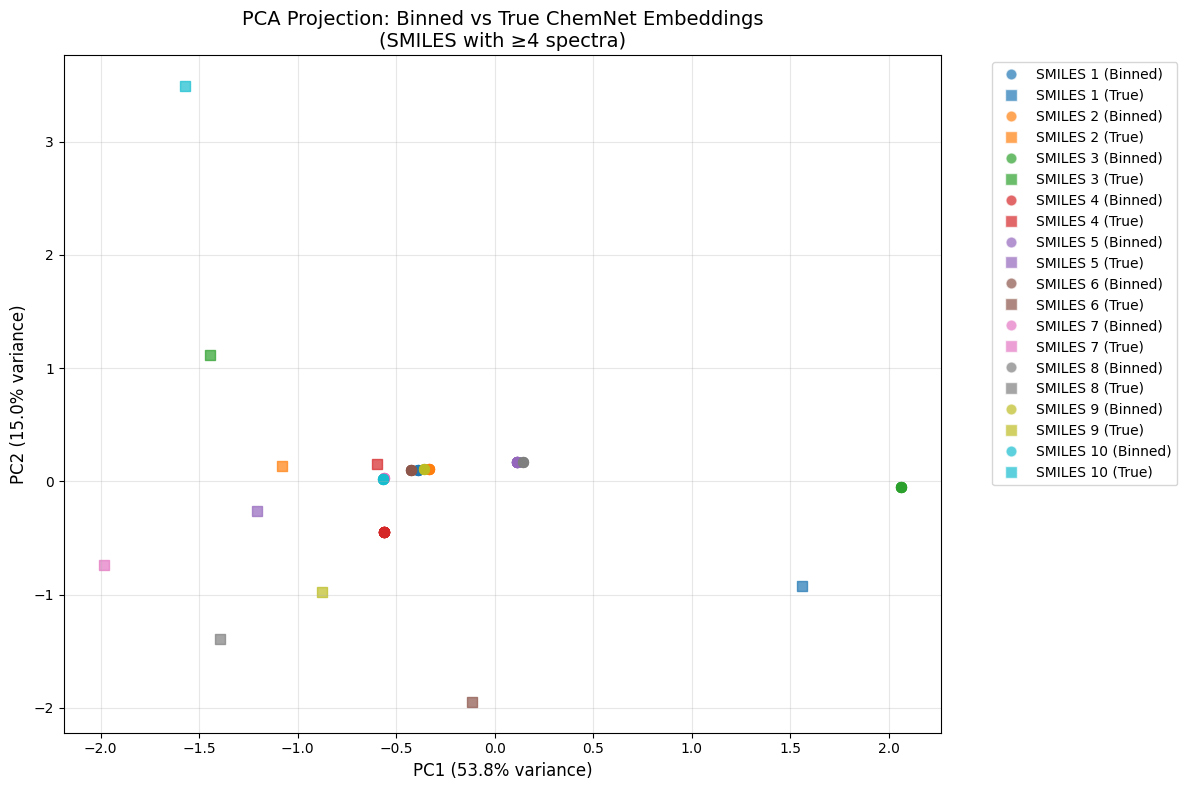

Binned Embeddings PCA explained variance: PC1=53.8%, PC2=15.0%
Binned Embeddings Total explained variance: 68.9%
True Embeddings PCA explained variance: PC1=7.5%, PC2=6.2%
True Embeddings Total explained variance: 13.7%


In [26]:
# Specify bin size and threshold
bin_size = 0.1 # Or bin sizes 1, 200
threshold = 100 # Or Thresholds 50, 100

# Build filename
folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"

if threshold == 0:
    filename = f"chemnet_emb_bin{str(bin_size).replace('.', '_')}_thresh_zero_df_spectra.pkl"
else:
    filename = f"chemnet_emb_bin{str(bin_size).replace('.', '_')}_thresh{str(threshold).replace('.', '_')}_df_spectra.pkl"

file_path = os.path.join(folder, filename)
df = pd.read_pickle(file_path)

# Load the true ChemNet embeddings
df5_chemnet = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet")

# Set minimum number of spectra threshold (changeable)
min_spectra_count = 4  # Change this value as needed

# Count spectra per SMILES
smiles_counts = df['SMILES_spectra'].value_counts()
print(f"SMILES with >= {min_spectra_count} spectra:")
frequent_smiles = smiles_counts[smiles_counts >= min_spectra_count]
print(f"Found {len(frequent_smiles)} SMILES with {min_spectra_count}+ spectra")
print(frequent_smiles.head(10))

# Filter dataset to only include SMILES with sufficient spectra
df_filtered = df[df['SMILES_spectra'].isin(frequent_smiles.index)]
print(f"Filtered dataset shape: {df_filtered.shape}")

# Prepare features for PCA (embedding columns)
feature_cols = [col for col in df_filtered.columns if col.startswith('emb_')]
X = df_filtered[feature_cols]

# Remove rows with NaN values
valid_mask = ~X.isna().any(axis=1)
X_clean = X[valid_mask]
smiles_clean = df_filtered.loc[valid_mask, 'SMILES_spectra']

# Perform PCA on binned embeddings
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clean)

# Now get the true ChemNet embeddings for the same SMILES
unique_smiles_filtered = smiles_clean.unique()
df5_chemnet_filtered = df5_chemnet[df5_chemnet['SMILES_spectra'].isin(unique_smiles_filtered)]

# Prepare true ChemNet embeddings for PCA
true_embedding_cols = [col for col in df5_chemnet_filtered.columns if col.startswith('Embedding Float')]
X_true = df5_chemnet_filtered[true_embedding_cols]

# Remove rows with NaN values in true embeddings
valid_mask_true = ~X_true.isna().any(axis=1)
X_true_clean = X_true[valid_mask_true]
smiles_true_clean = df5_chemnet_filtered.loc[valid_mask_true, 'SMILES_spectra']

# Perform PCA on true embeddings
pca_true = PCA(n_components=2, random_state=42)
X_true_pca = pca_true.fit_transform(X_true_clean)

# Create PCA plot colored by SMILES
plt.figure(figsize=(12, 8))

# Get unique SMILES and assign colors
unique_smiles = smiles_clean.unique()
colors = plt.cm.tab10(np.linspace(0, 1, min(len(unique_smiles), 10)))

# Plot each SMILES group
for i, smiles in enumerate(unique_smiles[:10]):  # Limit to first 10 for visibility
    # Plot binned embeddings as circles
    mask = smiles_clean == smiles
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=[colors[i]], label=f'SMILES {i+1} (Binned)', alpha=0.7, s=50, marker='o')
    
    # Plot true embeddings as squares for the same SMILES
    mask_true = smiles_true_clean == smiles
    if np.any(mask_true):
        plt.scatter(X_true_pca[mask_true, 0], X_true_pca[mask_true, 1], 
                   c=[colors[i]], alpha=0.7, s=50, marker='s', 
                   label=f'SMILES {i+1} (True)' if i == 0 else "")

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'PCA Projection: Binned vs True ChemNet Embeddings\n(SMILES with ≥{min_spectra_count} spectra)', fontsize=14)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = []
for i in range(min(len(unique_smiles), 10)):
    legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
                                 markersize=8, label=f'SMILES {i+1} (Binned)', alpha=0.7))
    legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor=colors[i], 
                                 markersize=8, label=f'SMILES {i+1} (True)', alpha=0.7))

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Binned Embeddings PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Binned Embeddings Total explained variance: {pca.explained_variance_ratio_.sum():.1%}")
print(f"True Embeddings PCA explained variance: PC1={pca_true.explained_variance_ratio_[0]:.1%}, PC2={pca_true.explained_variance_ratio_[1]:.1%}")
print(f"True Embeddings Total explained variance: {pca_true.explained_variance_ratio_.sum():.1%}")

In [27]:
df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet")
df.head()

,SMILES_spectra,Embedding Float 0,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,...,Embedding Float 502,Embedding Float 503,Embedding Float 504,Embedding Float 505,Embedding Float 506,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511
0,C#CCN(C)Cc1ccccc1,-0.081878,-0.000592,-0.115424,0.361975,-0.013771,0.068946,-0.079094,-0.639643,-0.616823,...,0.120262,0.757480,0.757137,-1.207158e-04,-0.201007,-0.281432,-0.574846,0.037261,0.048509,0.227904
1,c1ccc(CNc2[nH]cnc3ncnc2-3)cc1,0.276912,0.001158,0.184940,0.435511,-0.044371,0.079663,-0.325618,-0.039556,-0.027167,...,0.008954,-0.361290,0.692838,-6.056217e-04,-0.156619,-0.154309,0.284962,0.479151,0.132179,0.100753
2,c1coc(CNc2[nH]cnc3ncnc2-3)c1,0.343482,0.000665,0.109500,0.623262,-0.109757,0.112946,-0.418121,-0.035453,-0.004837,...,0.001494,-0.356037,0.435746,-1.227337e-03,0.135886,0.161948,0.331081,0.624193,0.150636,0.398498
3,c1ccc(CNc2ncnc3c2ncn3C2CCCCO2)cc1,-0.178223,0.005416,0.428077,0.479779,-0.162642,0.033273,-0.322550,-0.034872,-0.049524,...,0.002964,0.204067,0.215919,-1.736632e-02,0.542047,0.477724,-0.102496,0.484719,0.349642,-0.029105
4,c1cc(-c2ccncc2)ccn1,0.340481,0.000491,-0.096004,0.602171,-0.004242,0.101546,0.200853,-0.061073,-0.239671,...,0.034536,-0.191667,0.951767,8.522607e-07,-0.169929,-0.143720,-0.217218,-0.283479,0.141238,0.285142


# Dataset Exploration

In [28]:
# Choose your folder and dataset
folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"  # or grid_search_dataframes
dataset_name = "chemnet_emb_bin0_1_thresh0_1_df_spectra"  # change this to any dataset you want

# folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"  # or grid_search_dataframes
# dataset_name = "bin0_1_thresh0_1_df_spectra"  # change this to any dataset you want

# Load and display
file_path = os.path.join(folder, f"{dataset_name}.pkl")
df = pd.read_pickle(file_path)
print(f"Dataset: {dataset_name}")
print(f"Shape: {df.shape}")
df.head()

Dataset: chemnet_emb_bin0_1_thresh0_1_df_spectra
Shape: (3514, 516)


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511,SMILES_spectra,Response,log_response,index_id
0,-0.138372,-0.028126,-0.470714,0.355514,-0.192495,0.051052,-0.484355,-0.271956,-0.321912,0.206045,...,-0.426817,-0.102536,-0.334953,-0.600846,0.266666,-0.107150,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,213
1,-0.170064,0.009710,-0.455615,0.368871,-0.184370,0.027258,-0.474222,-0.266902,-0.319529,0.211004,...,-0.456274,-0.095278,-0.299249,-0.596987,0.280877,-0.056583,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,211
2,-0.152057,0.006864,-0.479647,0.332515,-0.185182,0.032891,-0.484368,-0.268179,-0.311028,0.219464,...,-0.456219,-0.089106,-0.313846,-0.622469,0.262479,-0.085211,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,214
3,0.305195,-0.009654,-0.202481,0.148799,-0.190394,0.079215,0.515682,-0.250115,-0.309730,0.429917,...,-0.061100,-0.086916,-0.455637,0.134329,0.139420,0.126727,C#CCOC(=O)[C@@H](C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,2125.857143,7.661930,2958
4,0.209256,-0.023982,-0.130968,0.044996,-0.272925,0.062253,0.499890,-0.227606,-0.309961,0.457334,...,-0.008089,-0.098894,-0.473902,0.231832,0.131747,0.040932,C#CCOC(=O)[C@@H](C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,2125.857143,7.661930,2961


In [29]:
# Check for NaN values in the current dataset
print(f"Dataset: {dataset_name}")
print(f"Shape: {df.shape}")

# Check which columns have NaN values
nan_cols = df.columns[df.isna().any()].tolist()
print(f"\nColumns with NaN values: {len(nan_cols)}")
print(f"Columns: {nan_cols}")

# Count NaN values per column
nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
print(f"\nNaN counts per column:")
print(nan_counts)

# Find rows that have ANY NaN values
rows_with_nan = df[df.isna().any(axis=1)]
print(f"\nRows with NaN values: {len(rows_with_nan)} out of {len(df)} total rows")

# Show the rows with NaN values
if len(rows_with_nan) > 0:
    print("\nFirst few rows with NaN values:")
    print(rows_with_nan.head())
    
    # Show which specific cells are NaN in these rows
    print("\nNaN pattern in first 5 rows with NaN:")
    for idx in rows_with_nan.index[:5]:
        nan_cols_in_row = df.loc[idx].isna()
        nan_cols_in_row = nan_cols_in_row[nan_cols_in_row].index.tolist()
        print(f"Row {idx}: NaN in columns {len(nan_cols_in_row)} columns: {nan_cols_in_row[:5]}...")
else:
    print("\nNo rows with NaN values found!")

Dataset: chemnet_emb_bin0_1_thresh0_1_df_spectra
Shape: (3514, 516)

Columns with NaN values: 0
Columns: []

NaN counts per column:
Series([], dtype: int64)

Rows with NaN values: 0 out of 3514 total rows

No rows with NaN values found!


In [30]:
df.head()

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511,SMILES_spectra,Response,log_response,index_id
0,-0.138372,-0.028126,-0.470714,0.355514,-0.192495,0.051052,-0.484355,-0.271956,-0.321912,0.206045,...,-0.426817,-0.102536,-0.334953,-0.600846,0.266666,-0.107150,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,213
1,-0.170064,0.009710,-0.455615,0.368871,-0.184370,0.027258,-0.474222,-0.266902,-0.319529,0.211004,...,-0.456274,-0.095278,-0.299249,-0.596987,0.280877,-0.056583,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,211
2,-0.152057,0.006864,-0.479647,0.332515,-0.185182,0.032891,-0.484368,-0.268179,-0.311028,0.219464,...,-0.456219,-0.089106,-0.313846,-0.622469,0.262479,-0.085211,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,214
3,0.305195,-0.009654,-0.202481,0.148799,-0.190394,0.079215,0.515682,-0.250115,-0.309730,0.429917,...,-0.061100,-0.086916,-0.455637,0.134329,0.139420,0.126727,C#CCOC(=O)[C@@H](C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,2125.857143,7.661930,2958
4,0.209256,-0.023982,-0.130968,0.044996,-0.272925,0.062253,0.499890,-0.227606,-0.309961,0.457334,...,-0.008089,-0.098894,-0.473902,0.231832,0.131747,0.040932,C#CCOC(=O)[C@@H](C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,2125.857143,7.661930,2961


In [31]:
folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_outputs"  
dataset_name = "cond_enc_bin0_1_thresh_zero_df_spectra"  # change this to any dataset you want

# Load and display
file_path = os.path.join(folder, f"{dataset_name}.pkl")
df = pd.read_pickle(file_path)
print(f"Dataset: {dataset_name}")
print(f"Shape: {df.shape}")
df.head()

Dataset: cond_enc_bin0_1_thresh_zero_df_spectra
Shape: (3623, 517)


,cond_emb_0,cond_emb_1,cond_emb_2,cond_emb_3,cond_emb_4,cond_emb_5,cond_emb_6,cond_emb_7,cond_emb_8,cond_emb_9,...,cond_emb_507,cond_emb_508,cond_emb_509,cond_emb_510,cond_emb_511,cond_tox_pred,SMILES_spectra,Response,log_response,index_id
0,0.033118,0.022494,-0.063117,0.088018,-0.159382,0.041483,-0.009025,-0.212029,-0.197349,-0.076352,...,-0.024438,-0.115313,0.071767,0.095526,0.062112,7.396009,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,0
1,0.084042,0.012930,-0.093678,0.088928,-0.149632,0.062432,-0.014132,-0.250264,-0.205067,-0.058158,...,-0.052411,-0.123212,0.089612,0.118023,0.031054,7.409180,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,1
2,0.031907,0.023363,-0.091554,0.097164,-0.165146,0.054193,-0.047529,-0.201955,-0.191119,-0.087268,...,-0.020571,-0.125351,0.053643,0.122142,0.081901,7.394979,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,1791.000000,7.490529,2
3,0.051878,0.002828,-0.143758,0.127078,-0.088120,0.047380,0.056158,-0.448648,-0.346472,-0.158874,...,-0.104092,-0.371172,0.294700,0.171130,0.135606,6.399325,C#CCN(C)Cc1ccccc1,273.642508,5.611823,3
4,0.023868,0.014705,-0.083653,0.094001,-0.061023,0.047156,0.091064,-0.373106,-0.326530,-0.146190,...,-0.069703,-0.310800,0.280322,0.141828,0.101854,5.558556,C#CCN(C)Cc1ccccc1,273.642508,5.611823,4


In [32]:
all_float = all(isinstance(c, float) for c in df.columns[1:-4])
print("All columns are float:", all_float)

# Select all columns except the first
spectra = df.iloc[:, 1:-4]

# Check if every element is a float
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)

All columns are float: False
All elements are float: True


# New Conditional Encoder Heatmap

/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/s

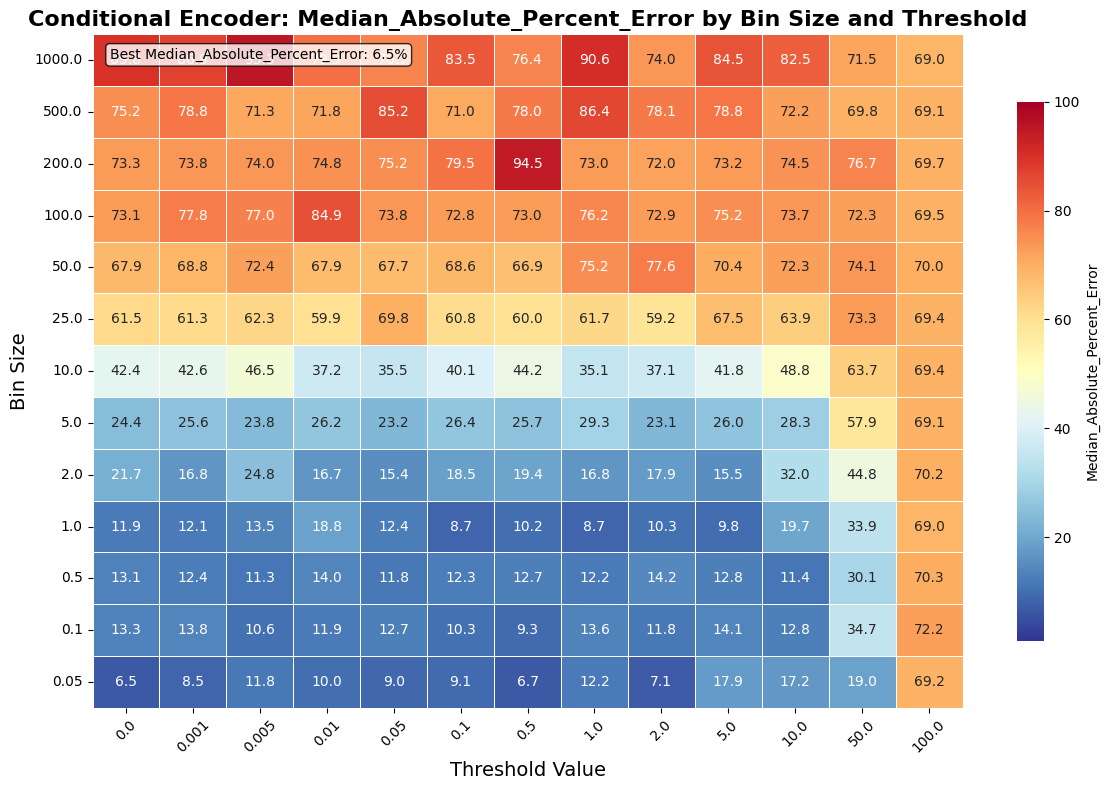

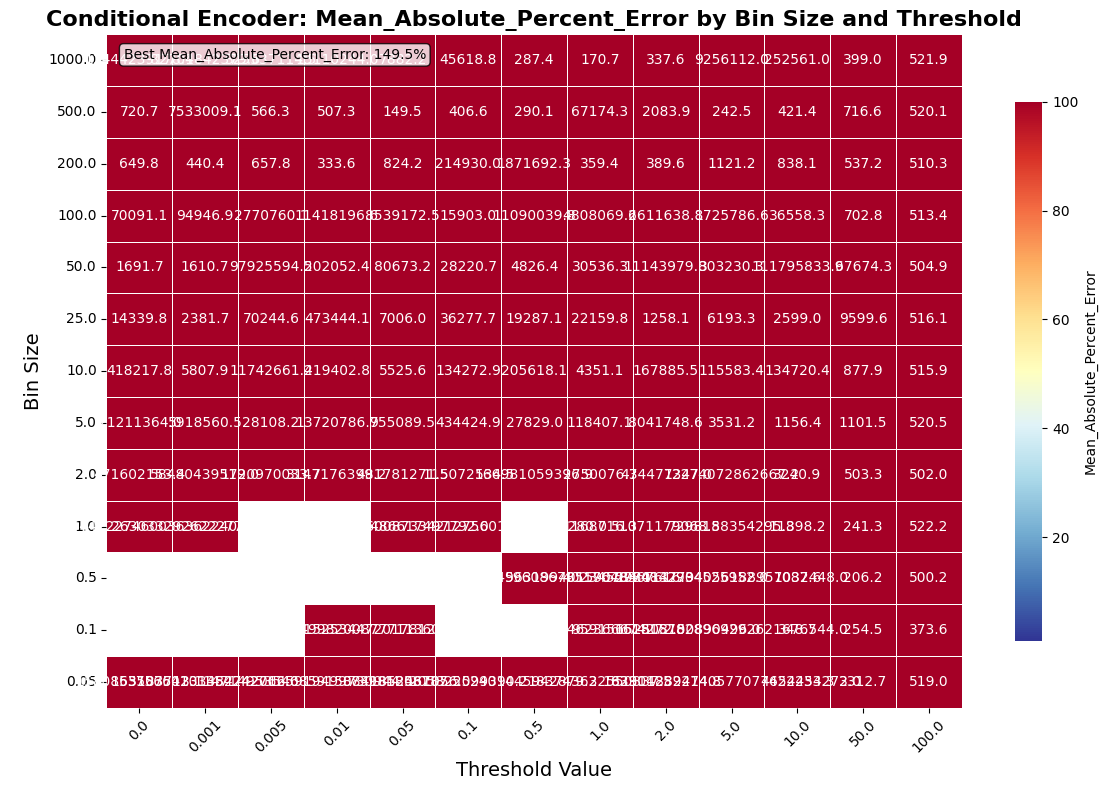

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load conditional encoder datasets folder path
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_outputs"

# Get all .pkl files in the folder
cond_enc_pkl_files = [f for f in os.listdir(cond_enc_folder) if f.endswith('.pkl')]
cond_enc_dataset_names = [f.replace('.pkl', '') for f in cond_enc_pkl_files]

# Initialize storage for conditional encoder results (percent error only)
cond_enc_results_percent_error = []

# Process conditional encoder datasets
for i, dataset_name in enumerate(sorted(cond_enc_dataset_names), 1):
    try:
        # Load the conditional encoder dataset
        file_path = os.path.join(cond_enc_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:  # Skip if too few samples
            continue
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate median and mean absolute percent error
        median_percent_error = np.median(individual_errors)
        mean_percent_error = np.mean(individual_errors)
        
        # Store results
        cond_enc_results_percent_error.append({
            'Dataset': dataset_name,
            'Median_Percent_Error': median_percent_error,
            'Mean_Percent_Error': mean_percent_error,
            'Samples': len(y_pred_response_clean)
        })
        
    except Exception as e:
        continue

# Convert results to DataFrame
df_cond_enc_percent_error_results = pd.DataFrame(cond_enc_results_percent_error)

# Function to parse conditional encoder dataset names
def parse_cond_enc_dataset_name(dataset_name):
    """Extract bin size and threshold from conditional encoder dataset name"""
    # Remove 'cond_enc_' prefix
    name_part = dataset_name.replace('cond_enc_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns
bin_sizes = []
thresholds = []

for dataset_name in df_cond_enc_percent_error_results['Dataset']:
    bin_size, threshold = parse_cond_enc_dataset_name(dataset_name)
    bin_sizes.append(bin_size)
    thresholds.append(threshold)

df_cond_enc_percent_error_results['BinSize'] = bin_sizes
df_cond_enc_percent_error_results['Threshold'] = thresholds

# Remove duplicates
df_cond_enc_percent_error_results = df_cond_enc_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

# Create pivot tables
cond_enc_median_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Median_Percent_Error')
cond_enc_mean_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Mean_Percent_Error')

# List all expected thresholds and bin sizes
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables
cond_enc_median_percent_error_pivot = cond_enc_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
cond_enc_mean_percent_error_pivot = cond_enc_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Function to create heatmaps
def create_detailed_heatmap_cond_enc(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single Conditional Encoder metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'{metric_name}', 'shrink': 0.8})
    
    plt.title(f'Conditional Encoder: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_val = pivot_data.min().min()
    plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    # plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/CondEnc_{metric_name}_by_Bin_Size_and_Threshold.png", 
    #             dpi=300, bbox_inches='tight')
    plt.show()

# Create heatmaps
create_detailed_heatmap_cond_enc(cond_enc_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_cond_enc(cond_enc_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)